<a href="https://colab.research.google.com/github/ehas1/Statistical-Bias-in-ML/blob/main/LIME_and_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
! pip install lime
import lime.lime_tabular
import shap
! pip install scikit-learn
from sklearn.decomposition import PCA
import xgboost as xgb
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
import os
import glob
import joblib
from pathlib import Path
import requests
from io import StringIO

# Visualization Settings
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Global Configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [4]:
# Storage and Model Loading Setup
def setup_storage():
    """Set up storage access for model files."""
    # First try the local COMPAS_models directory in the current working directory
    models_dir = os.path.join(os.getcwd(), 'COMPAS_models')

    if not os.path.exists(models_dir):
        # Try home directory
        models_dir = os.path.join(os.path.expanduser('~'), 'Desktop/OAIP/Statistical-Bias-in-ML/COMPAS_models')

    # Create the models directory if it doesn't exist
    if not os.path.exists(models_dir):
        os.makedirs(models_dir)
        print(f"Created models directory at {models_dir}")

    print(f"Using models directory: {models_dir}")
    return models_dir

def find_latest_model(pattern: str, models_dir: str = None) -> str:
    """Find the most recent model file matching the given pattern."""
    # Try multiple possible paths
    colab_path = "/content/gdrive/MyDrive/COMPAS_models"
    local_path = os.path.join(os.path.expanduser('~'), 'COMPAS_models')
    current_dir_path = os.path.join(os.getcwd(), 'COMPAS_models')

    # Use provided models_dir, or try all possible paths
    search_paths = [p for p in [models_dir, colab_path, local_path, current_dir_path] if p]

    print(f"\nSearching for pattern: {pattern}")
    print("Checking directories:")

    for path in search_paths:
        print(f"Checking {path}...")
        if os.path.exists(path):
            print(f"Directory exists: {path}")
            # List all files in directory
            print("Files in directory:")
            for f in os.listdir(path):
                print(f"  - {f}")

            # Try to find matching files
            full_pattern = os.path.join(path, pattern)
            files = glob.glob(full_pattern)
            if files:
                print(f"Found files matching {pattern}:")
                for f in files:
                    print(f"  - {f}")
                latest = max(files, key=os.path.getctime)
                print(f"Selected latest file: {latest}")
                # Check if it's a metadata file
                if 'metadata' in latest:
                    print("Warning: Selected file is a metadata file, skipping...")
                    continue
                return latest
        else:
            print(f"Directory does not exist: {path}")

    raise FileNotFoundError(f"No model files found matching pattern: {pattern}")

def load_all_models() -> tuple:
    """Load all models including bias-specific decision trees."""
    try:
        models_dir = setup_storage()
        # Load bias-specific decision tree models
        sex_bias_model_path = find_latest_model('sex_bias_decision_tree_model_*[!metadata].joblib')
        racial_bias_model_path = find_latest_model('racial_bias_decision_tree_model_*[!metadata].joblib')

        # Try to find XGBoost model with different possible extensions
        try:
            xgb_model_path = find_latest_model('xgboost_model_*[!metadata].ubj')
        except FileNotFoundError:
            try:
                xgb_model_path = find_latest_model('xgboost_model_*[!metadata].json')
            except FileNotFoundError:
                xgb_model_path = find_latest_model('xgboost_model_*[!metadata].*')

        nn_model_path = find_latest_model('neural_network_model_*.keras')

        print("Loading models from:")
        print(f"Sex Bias Decision Tree: {sex_bias_model_path}")
        print(f"Racial Bias Decision Tree: {racial_bias_model_path}")
        print(f"XGBoost: {xgb_model_path}")
        print(f"Neural Network: {nn_model_path}")

        # Load decision tree models
        sex_bias_model = joblib.load(sex_bias_model_path)
        racial_bias_model = joblib.load(racial_bias_model_path)
        print("Successfully loaded bias-specific decision tree models")

        # Load XGBoost model
        try:
            wrapped_xgb = xgb.XGBClassifier(
                objective='binary:logistic',
                use_label_encoder=False
            )
            wrapped_xgb.load_model(str(xgb_model_path))
            print("Successfully loaded XGBoost model")
        except Exception as e:
            print(f"Error loading XGBoost model: {str(e)}")
            try:
                print("Attempting alternative loading method...")
                booster = xgb.Booster()
                booster.load_model(str(xgb_model_path))
                wrapped_xgb = xgb.XGBClassifier(
                    objective='binary:logistic',
                    use_label_encoder=False
                )
                wrapped_xgb._Booster = booster
                wrapped_xgb.n_classes_ = 2
                print("Successfully loaded XGBoost model using alternative method")
            except Exception as e2:
                print(f"Alternative loading method also failed: {str(e2)}")
                raise

        # Load Neural Network model
        nn_model = load_model(nn_model_path)
        print("Successfully loaded Neural Network model")

        return sex_bias_model, racial_bias_model, wrapped_xgb, nn_model

    except Exception as e:
        print(f"Error loading models: {str(e)}")
        print("Please ensure the models are saved in either:")
        print("- Google Colab: /content/drive/MyDrive/COMPAS_models/")
        print(f"- Local: {os.path.join(os.path.expanduser('~'), 'COMPAS_models')}")
        raise

# Mount Google Drive to access models
from google.colab import drive
drive.mount('/content/gdrive')
print("Google Drive mounted.")


# Set up storage and update the global models directory
MODELS_DIR = setup_storage()

# Load all models
sex_bias_model, racial_bias_model, xgb_model, nn_model = load_all_models()

# Create models dictionary
models_dict = {
    'sex_bias_dt': sex_bias_model,
    'racial_bias_dt': racial_bias_model,
    'xgb': xgb_model,
    'nn': nn_model
}

Mounted at /content/gdrive
Google Drive mounted.
Created models directory at /root/Desktop/OAIP/Statistical-Bias-in-ML/COMPAS_models
Using models directory: /root/Desktop/OAIP/Statistical-Bias-in-ML/COMPAS_models
Using models directory: /root/Desktop/OAIP/Statistical-Bias-in-ML/COMPAS_models

Searching for pattern: sex_bias_decision_tree_model_*[!metadata].joblib
Checking directories:
Checking /content/gdrive/MyDrive/COMPAS_models...
Directory exists: /content/gdrive/MyDrive/COMPAS_models
Files in directory:
  - decision_tree_model_20250806_005108.joblib
  - decision_tree_model_20250806_005108_metadata.json
  - racial_bias_decision_tree_model_20250916_185826.joblib
  - racial_bias_decision_tree_model_20250916_185826_metadata.json
  - sex_bias_decision_tree_model_20250916_185827.joblib
  - sex_bias_decision_tree_model_20250916_185827_metadata.json
  - xgboost_model_20250916_185830.joblib
  - xgboost_model_20250916_185830_metadata.json
  - neural_network_model_20250916_190044.keras
  - n

In [5]:
# Data Loading and Preprocessing Functions
def load_data(url="https://raw.githubusercontent.com/propublica/compas-analysis/refs/heads/master/cox-violent-parsed.csv"):
    """Load the COMPAS dataset from ProPublica's repository."""
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = pd.read_csv(StringIO(response.text))
        print(f"Successfully loaded data with shape: {data.shape}")
        return data
    except Exception as e:
        print(f"Error loading data: {str(e)}")
        raise

def preprocess_data(data):
    """Preprocess the COMPAS dataset for model interpretation."""
    # Print available columns for debugging
    print("Available columns in dataset:", data.columns.tolist())

    # Define required columns and their expected categories
    required_features = [
        'age',
        'c_charge_degree',
        'race',
        'sex',
        'priors_count',
        'juv_other_count',
        'juv_fel_count',
        'juv_misd_count',
        'decile_score'
    ]
    target = 'is_recid'

    # Define expected categories for categorical variables
    expected_categories = {
        'c_charge_degree': ['F', 'M'],  # Felony and Misdemeanor
        'race': ['African-American', 'Caucasian', 'Hispanic', 'Other'],
        'sex': ['Female', 'Male']
    }

    # Define the exact expected feature set for the neural network (14 features)
    expected_features = [
        # Numerical features
        'age', 'priors_count',
        # Charge degree features (all categories)
        'c_charge_degree_F', 'c_charge_degree_M',
        # Race features (all categories)
        'race_African-American', 'race_Caucasian', 'race_Hispanic', 'race_Other',
        # Sex features (all categories)
        'sex_Female', 'sex_Male',
        # Additional features that might be expected by the model
        'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'decile_score'
    ]

    # Validate required columns exist
    missing_cols = [col for col in required_features + [target] if col not in data.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    # Preprocessing pipeline
    print("\nPreprocessing steps:")

    # 1. Handle missing values
    print("1. Handling missing values...")
    for col in required_features:
        if data[col].isnull().any():
            if pd.api.types.is_numeric_dtype(data[col]):
                data[col].fillna(data[col].mean(), inplace=True)
            else:
                data[col].fillna(data[col].mode()[0], inplace=True)

    # 2. Convert categorical variables with controlled encoding
    print("2. Converting categorical variables...")
    data_processed = data[required_features].copy()

    # Ensure categories are mapped correctly
    data_processed['race'] = data_processed['race'].map(lambda x: 'Other' if x not in expected_categories['race'] else x)
    data_processed['c_charge_degree'] = data_processed['c_charge_degree'].map(lambda x: 'F' if x not in expected_categories['c_charge_degree'] else x)
    data_processed['sex'] = data_processed['sex'].map(lambda x: 'Male' if x not in expected_categories['sex'] else x)

    # First handle numerical features
    numerical_features = ['age', 'priors_count', 'decile_score']

    # Create a new DataFrame with just numerical features
    data_processed_new = pd.DataFrame()

    # Add numerical features
    for feature in numerical_features:
        if feature in data.columns:
            data_processed_new[feature] = data[feature]
        else:
            print(f"Warning: {feature} not found in data, filling with zeros")
            data_processed_new[feature] = 0

    # Create dummy variables for categorical features
    for cat_col, categories in expected_categories.items():
        # Create dummy variables
        dummies = pd.get_dummies(
            data_processed[cat_col],
            prefix=cat_col,
            prefix_sep='_'
        )

        # Ensure all expected categories exist
        for category in categories:
            col_name = f"{cat_col}_{category}"
            if col_name not in dummies.columns:
                dummies[col_name] = 0

        # Add to processed data
        data_processed_new = pd.concat([data_processed_new, dummies], axis=1)

    # Ensure all expected features are present and in correct order
    missing_features = set(expected_features) - set(data_processed_new.columns)
    if missing_features:
        print(f"Warning: Adding missing features: {missing_features}")
        for feature in missing_features:
            data_processed_new[feature] = 0

    # Reorder columns to match expected feature order
    data_processed = data_processed_new[expected_features]

    print("\nVerifying features:")
    print(f"Expected features: {len(expected_features)}")
    print(f"Actual features: {len(data_processed.columns)}")
    print("\nFeatures in processed data:")
    for i, col in enumerate(data_processed.columns, 1):
        print(f"{i}. {col}")

    # Print the expected feature set
    print("\nFeature set after preprocessing:")
    print(data_processed.columns.tolist())

    # 3. Normalize numerical features
    print("3. Normalizing numerical features...")
    numerical_features = ['age', 'priors_count', 'decile_score']
    for col in numerical_features:
        data_processed[col] = (data_processed[col] - data_processed[col].mean()) / data_processed[col].std()

    # 4. Split into features and target
    print("4. Preparing train-test split...")
    # Convert to float32 for neural network compatibility
    X = data_processed.astype(np.float32)
    y = data[target]

    # Print feature columns for verification
    print("\nFeature columns after preprocessing:")
    print(X.columns.tolist())
    print(f"Number of features: {len(X.columns)}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\nPreprocessing complete:")
    print(f"Training set shape: {X_train.shape}")
    print(f"Test set shape: {X_test.shape}")

    return (X_train, y_train), (X_test, y_test)

# Load and preprocess data
print("Loading and preprocessing data...")
data = load_data()
(X_train, y_train), (X_test, y_test) = preprocess_data(data)
feature_names = X_train.columns.tolist()


Loading and preprocessing data...
Successfully loaded data with shape: (18316, 52)
Available columns in dataset: ['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event']

Preprocessing steps:
1. Handling missing values...
2. Converting categori

/tmp/ipython-input-86841138.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [6]:
# Load models and verify compatibility
def verify_model_compatibility(X_sample, models):
    """Verify that the preprocessed data matches the expected input shapes of the models."""
    print("Verifying model compatibility...")

    # Get the number of features in the preprocessed data
    n_features = X_sample.shape[1]
    print(f"\nPreprocessed data has {n_features} features")
    print(f"Input data types:")
    for col in X_sample.columns:
        print(f"  {col}: {X_sample[col].dtype}")

    # Convert data to numpy array and ensure float32 type
    X_single = X_sample.values[:1].astype(np.float32)

    # Check Sex Bias Decision Tree model
    try:
        sex_bias_pred = models['sex_bias_dt'].predict_proba(X_single)
        print("✓ Sex Bias Decision Tree model compatible")
        print(f"Sex Bias model prediction shape: {sex_bias_pred.shape}")
    except Exception as e:
        print(f"✗ Sex Bias Decision Tree model error: {str(e)}")

    # Check Racial Bias Decision Tree model
    try:
        racial_bias_pred = models['racial_bias_dt'].predict_proba(X_single)
        print("✓ Racial Bias Decision Tree model compatible")
        print(f"Racial Bias model prediction shape: {racial_bias_pred.shape}")
    except Exception as e:
        print(f"✗ Racial Bias Decision Tree model error: {str(e)}")

    # Check XGBoost model
    try:
        xgb_pred = models['xgb'].predict_proba(X_single)
        print("✓ XGBoost model compatible")
        print(f"XGBoost prediction shape: {xgb_pred.shape}")
    except Exception as e:
        print(f"✗ XGBoost model error: {str(e)}")

    # Check Neural Network model
    try:
        # Get input shape from the model's input layer
        nn_input_shape = models['nn'].input_shape[1]
        print(f"\nNeural Network expects {nn_input_shape} features")
        if nn_input_shape != n_features:
            print(f"✗ Neural Network input shape mismatch: expected {nn_input_shape}, got {n_features}")
            print("\nFeature columns in preprocessed data:")
            print(X_sample.columns.tolist())
            raise ValueError(f"Neural Network expects {nn_input_shape} features but got {n_features}")

        # Try prediction with proper data type
        nn_pred = models['nn'].predict(X_single)
        print("✓ Neural Network model compatible")
        print(f"Neural Network prediction shape: {nn_pred.shape}")
    except Exception as e:
        print(f"✗ Neural Network model error: {str(e)}")
        print("\nDebug information:")
        print(f"Input shape: {X_single.shape}")
        print(f"Input data type: {X_single.dtype}")
        print(f"Model summary:")
        models['nn'].summary()
        raise

# Verify compatibility of all models
print("Verifying model compatibility...")
verify_model_compatibility(X_train, models_dict)


Verifying model compatibility...
Verifying model compatibility...

Preprocessed data has 14 features
Input data types:
  age: float32
  priors_count: float32
  c_charge_degree_F: float32
  c_charge_degree_M: float32
  race_African-American: float32
  race_Caucasian: float32
  race_Hispanic: float32
  race_Other: float32
  sex_Female: float32
  sex_Male: float32
  juv_fel_count: float32
  juv_misd_count: float32
  juv_other_count: float32
  decile_score: float32
✓ Sex Bias Decision Tree model compatible
Sex Bias model prediction shape: (1, 2)
✓ Racial Bias Decision Tree model compatible
Racial Bias model prediction shape: (1, 2)
✓ XGBoost model compatible
XGBoost prediction shape: (1, 2)

Neural Network expects 14 features


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
✓ Neural Network model compatible
Neural Network prediction shape: (1, 1)


In [7]:
# LIME and SHAP Setup Functions
def setup_explainers(X_train, feature_names, models):
    """Set up LIME and SHAP explainers for all models"""
    # LIME explainer setup
    # Since data is already one-hot encoded and normalized, treat features as numerical for LIME
    # Remove categorical_features and categorical_names to avoid errors with one-hot encoded data
    lime_exp = lime.lime_tabular.LimeTabularExplainer(
        X_train.values,
        feature_names=feature_names,
        class_names=['No Recidivism', 'Recidivism'],
        mode='classification',
        discretize_continuous=False,  # Don't discretize since we've already normalized
        sample_around_instance=False,  # Don't sample around instance to avoid scale issues
        kernel_width=0.75 * np.sqrt(X_train.shape[1]),  # Scale kernel width with feature count
        verbose=False
    )

    # SHAP explainers
    def nn_predict_wrapper(x):
        pred = models['nn'].predict(x.astype(np.float32))
        if pred.shape[1] == 1:
            # If single output, convert to two-class probability
            return np.hstack([1 - pred, pred])
        return pred

    shap_exp = {
        'sex_bias_dt': shap.TreeExplainer(models['sex_bias_dt']),
        'racial_bias_dt': shap.TreeExplainer(models['racial_bias_dt']),
        'xgb': shap.TreeExplainer(models['xgb']),
        'nn': shap.KernelExplainer(
            nn_predict_wrapper,
            shap.sample(X_train, 100, random_state=42),
            link="logit"
        )
    }

    return lime_exp, shap_exp

def plot_global_importance(X_train, lime_exp, shap_exp, models, feature_names, focus_bias=None):
    """
    Plot global feature importance using LIME and SHAP

    Parameters:
    -----------
    focus_bias : str, optional
        Can be 'sex', 'racial', or None. If specified, highlights features related to that type of bias.
    """
    # Define bias-related features
    sex_bias_features = ['sex_Female', 'sex_Male']
    racial_bias_features = ['race_African-American', 'race_Caucasian', 'race_Hispanic', 'race_Other']

    fig, axes = plt.subplots(2, 1, figsize=(15, 12))
    title = 'Global Feature Importance Comparison'
    if focus_bias:
        title += f' (Focus on {focus_bias.capitalize()} Bias)'
    fig.suptitle(title, fontsize=14)

    # SHAP importance
    plt.sca(axes[0])
    shap_values = {}
    for name, explainer in shap_exp.items():
        if focus_bias:
            if focus_bias == 'sex' and 'racial_bias' in name:
                continue
            if focus_bias == 'racial' and 'sex_bias' in name:
                continue

        data = X_train if name != 'nn' else shap.sample(X_train, 100)
        values = explainer.shap_values(data)
        if isinstance(values, list):
            values = values[1]
        shap_values[name] = np.abs(values).mean(0)

    # Plot SHAP importance with highlighting
    shap_df = pd.DataFrame(shap_values, index=feature_names)
    ax = shap_df.plot(kind='bar', ax=axes[0])
    axes[0].set_title('SHAP Global Feature Importance')
    axes[0].set_xlabel('Features')
    axes[0].set_ylabel('Mean |SHAP value|')

    # Highlight bias-related features
    if focus_bias:
        highlight_features = sex_bias_features if focus_bias == 'sex' else racial_bias_features
        for i, feature in enumerate(feature_names):
            if feature in highlight_features:
                ax.patches[i].set_facecolor('red')
                ax.patches[i].set_alpha(0.7)

    # LIME importance
    X_sample = X_train.sample(n=100, random_state=42)
    lime_values = {name: np.zeros(len(feature_names)) for name in models if not focus_bias or
                  (focus_bias == 'sex' and 'racial_bias' not in name) or
                  (focus_bias == 'racial' and 'sex_bias' not in name)}

    for x in X_sample.values:
        for name, model in models.items():
            if name not in lime_values:
                continue
            predict_fn = model.predict_proba if name != 'nn' else model.predict
            exp = lime_exp.explain_instance(x, predict_fn, num_features=len(feature_names))
            for feat, imp in exp.as_list():
                # Use regex to extract feature name, handling potential < or > signs and numerical values
                match = re.match(r'([a-zA-Z_]+)', feat)
                if match:
                  fname = match.group(1)
                  if fname in feature_names:
                      idx = feature_names.index(fname)
                      lime_values[name][idx] += abs(imp)


    # Plot LIME importance with highlighting
    lime_df = pd.DataFrame(lime_values, index=feature_names)
    ax = lime_df.plot(kind='bar', ax=axes[1])
    axes[1].set_title('LIME Global Feature Importance')
    axes[1].set_xlabel('Features')
    axes[1].set_ylabel('Cumulative |importance|')

    # Highlight bias-related features
    if focus_bias:
        highlight_features = sex_bias_features if focus_bias == 'sex' else racial_bias_features
        for i, feature in enumerate(feature_names):
            if feature in highlight_features:
                ax.patches[i].set_facecolor('red')
                ax.patches[i].set_alpha(0.7)

    plt.tight_layout()
    plt.show()

def analyze_bias_impact(X_test, y_test, models, feature_names, bias_type='sex'):
    """
    Analyze the impact of bias-related features on model predictions

    Parameters:
    -----------
    bias_type : str
        Either 'sex' or 'racial'
    """
    # Select relevant features and model based on bias type
    if bias_type == 'sex':
        bias_features = ['sex_Female', 'sex_Male']
        bias_model = models['sex_bias_dt']
        model_name = 'Sex Bias DT'
    else:
        bias_features = ['race_African-American', 'race_Caucasian', 'race_Hispanic', 'race_Other']
        bias_model = models['racial_bias_dt']
        model_name = 'Racial Bias DT'

    # Get feature indices
    bias_indices = [feature_names.index(f) for f in bias_features]

    # Make predictions
    y_pred = bias_model.predict(X_test)

    # Calculate overall metrics
    from sklearn.metrics import classification_report, confusion_matrix
    print(f"\nModel Performance Analysis ({model_name}):")
    print("-" * 50)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Analyze predictions by protected attributes
    print(f"\nPrediction Distribution by {bias_type.capitalize()} Categories:")
    for feature in bias_features:
        feature_idx = feature_names.index(feature)
        subset_mask = X_test.iloc[:, feature_idx] == 1
        subset_pred = y_pred[subset_mask]
        subset_true = y_test[subset_mask]

        print(f"\n{feature} Analysis:")
        print(f"Total samples: {len(subset_pred)}")
        print(f"Predicted recidivism rate: {(subset_pred == 1).mean():.3f}")
        print(f"Actual recidivism rate: {(subset_true == 1).mean():.3f}")
        print("\nConfusion Matrix:")
        print(confusion_matrix(subset_true, subset_pred))

# Initialize explainers
print("Setting up LIME and SHAP explainers...")
lime_exp, shap_exp = setup_explainers(X_train, feature_names, models_dict)

# Print available models for analysis
print("\nAvailable models for analysis:")
for model_name in models_dict.keys():
    print(f"- {model_name}")

Setting up LIME and SHAP explainers...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step 

Available models for analysis:
- sex_bias_dt
- racial_bias_dt
- xgb
- nn



Analyzing 5 random instances...

Instance 2144 (True label: No Recidivism)

Actual dataset values:
id                                                  1293
name                                      zachary whalen
first                                            zachary
last                                              whalen
compas_screening_date                         2014-03-29
sex                                                 Male
dob                                           1991-09-03
age                                                   24
age_cat                                     Less than 25
race                                    African-American
juv_fel_count                                          0
decile_score                                           5
juv_misd_count                                         1
juv_other_count                                        0
priors_count                                           5
days_b_screening_arrest                      

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



Debug - Prediction shapes:
Sex Bias DT pred shape: (1, 2)
Racial Bias DT pred shape: (1, 2)
XGB pred shape: (1, 2)
NN pred shape: (1, 1)

Predictions:
----------------------------------------
SEX_BIAS_DT     : 0.340
RACIAL_BIAS_DT  : 0.258
XGB             : 0.380
NN              : 0.076


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


SHAP values shape: (1, 14, 2)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


SHAP values shape: (1, 14, 2)
SHAP values shape: (1, 14)
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
SHAP values shape: (1, 14, 2)


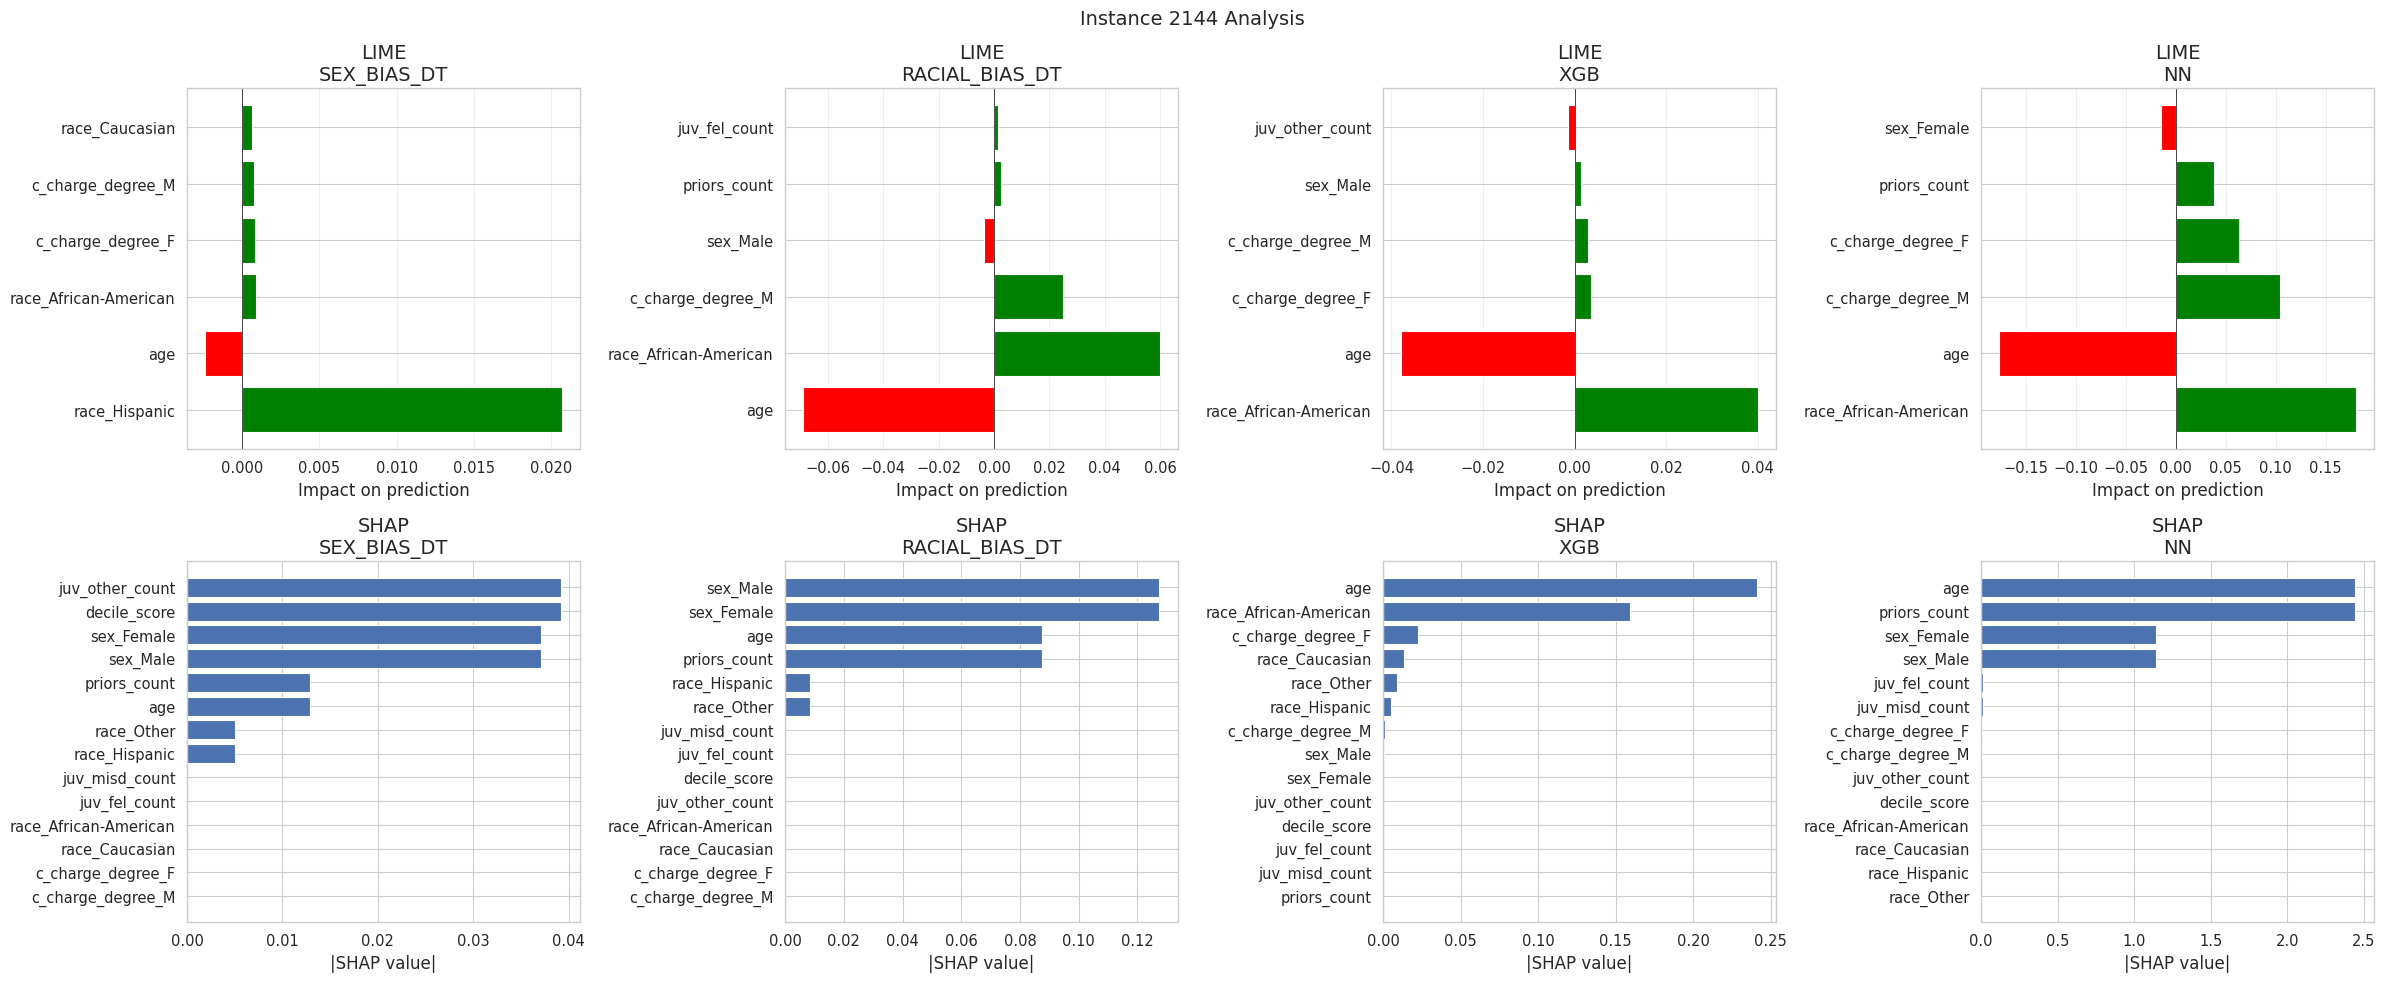


Instance 2596 (True label: No Recidivism)

Actual dataset values:
id                                          1566
name                               ulysses davis
first                                    ulysses
last                                       davis
compas_screening_date                 2013-11-19
sex                                         Male
dob                                   1959-05-04
age                                           56
age_cat                          Greater than 45
race                            African-American
juv_fel_count                                  0
decile_score                                   3
juv_misd_count                                 0
juv_other_count                                0
priors_count                                   8
days_b_screening_arrest                   -106.0
c_jail_in                    2013-08-05 07:30:16
c_jail_out                   2013-10-16 11:44:03
c_case_number                      08021349CF10A
c_

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

Debug - Prediction shapes:
Sex Bias DT pred shape: (1, 2)
Racial Bias DT pred shape: (1, 2)
XGB pred shape: (1, 2)
NN pred shape: (1, 1)

Predictions:
----------------------------------------
SEX_BIAS_DT     : 0.340
RACIAL_BIAS_DT  : 0.375
XGB             : 0.494
NN              : 0.651


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


SHAP values shape: (1, 14, 2)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


SHAP values shape: (1, 14, 2)
SHAP values shape: (1, 14)
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step
SHAP values shape: (1, 14, 2)


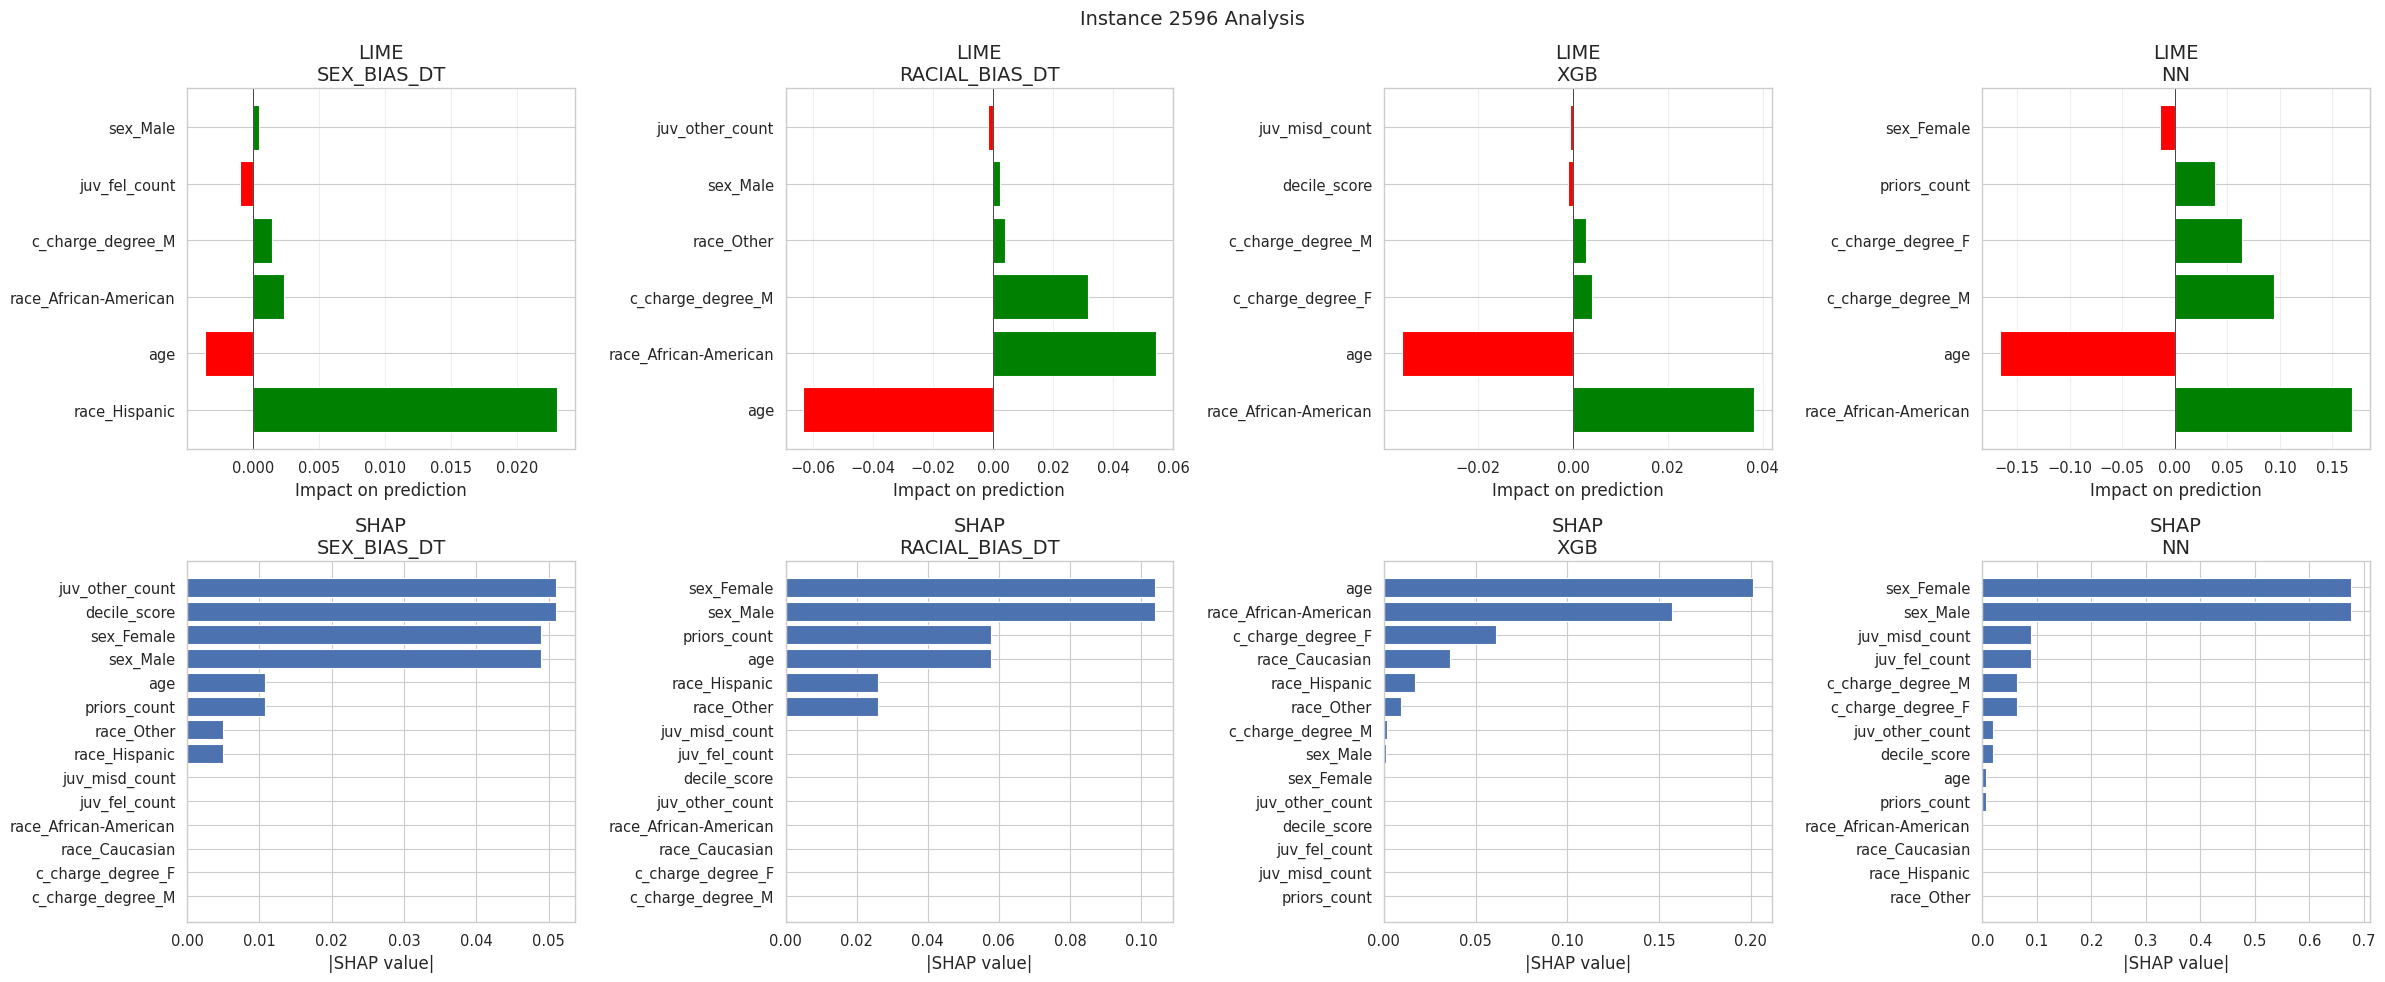


Instance 2024 (True label: Recidivism)

Actual dataset values:
id                                       1224
name                           stanley blaise
first                                 stanley
last                                   blaise
compas_screening_date              2014-11-29
sex                                      Male
dob                                1982-09-05
age                                        33
age_cat                               25 - 45
race                         African-American
juv_fel_count                               0
decile_score                                3
juv_misd_count                              0
juv_other_count                             0
priors_count                                0
days_b_screening_arrest                   NaN
c_jail_in                                 NaN
c_jail_out                                NaN
c_case_number                             NaN
c_offense_date                            NaN
c_arrest_date   

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


SHAP values shape: (1, 14, 2)
SHAP values shape: (1, 14, 2)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


SHAP values shape: (1, 14)
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
SHAP values shape: (1, 14, 2)


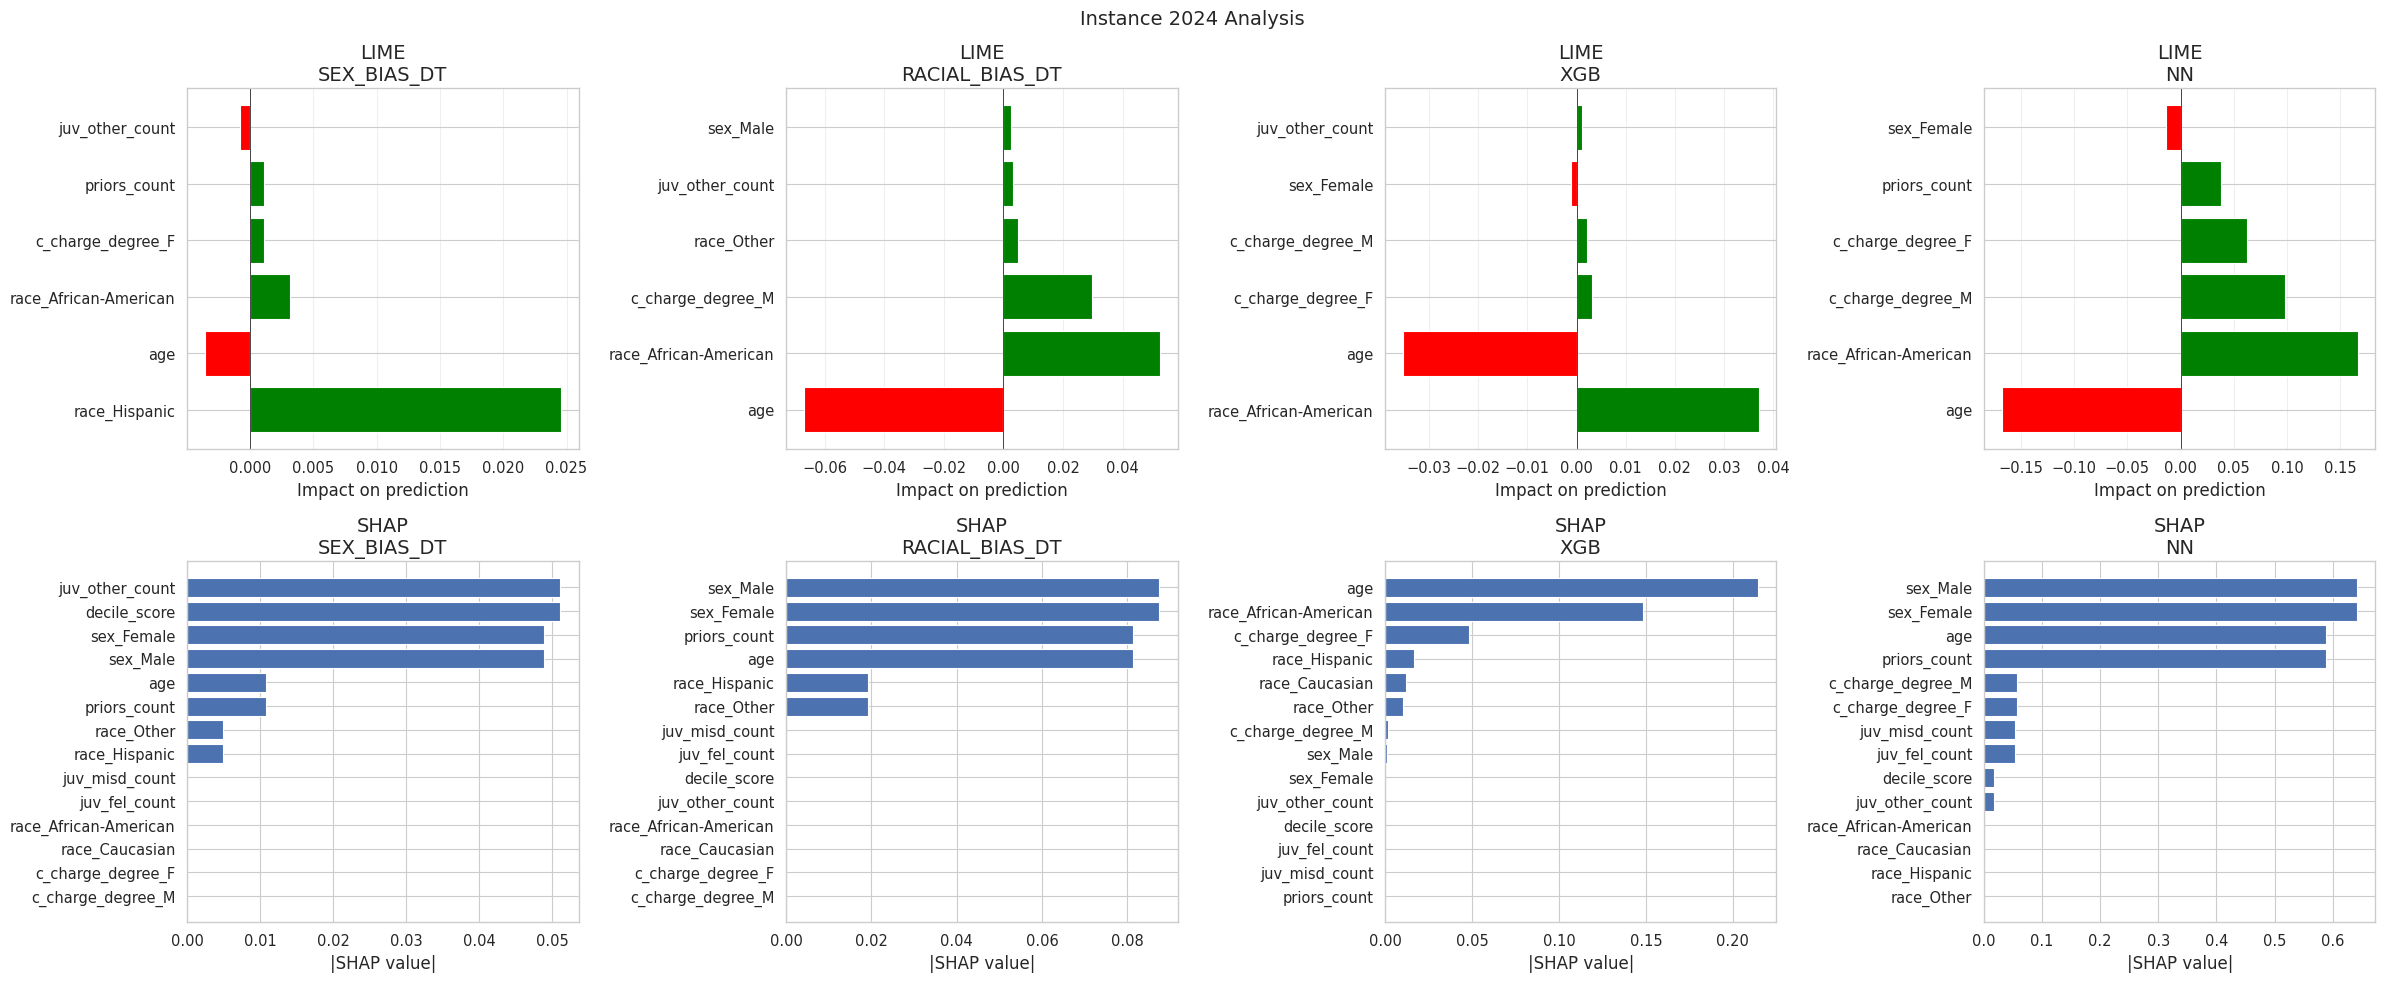


Instance 2646 (True label: Recidivism)

Actual dataset values:
id                                        1601
name                             russell adams
first                                  russell
last                                     adams
compas_screening_date               2013-05-08
sex                                       Male
dob                                 1983-11-10
age                                         32
age_cat                                25 - 45
race                                 Caucasian
juv_fel_count                                0
decile_score                                 2
juv_misd_count                               0
juv_other_count                              0
priors_count                                 2
days_b_screening_arrest                   -1.0
c_jail_in                  2013-05-07 02:17:32
c_jail_out                 2013-05-12 07:15:28
c_case_number                    13008853MM10A
c_offense_date                      2013-05

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


SHAP values shape: (1, 14, 2)
SHAP values shape: (1, 14, 2)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


SHAP values shape: (1, 14)
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
SHAP values shape: (1, 14, 2)


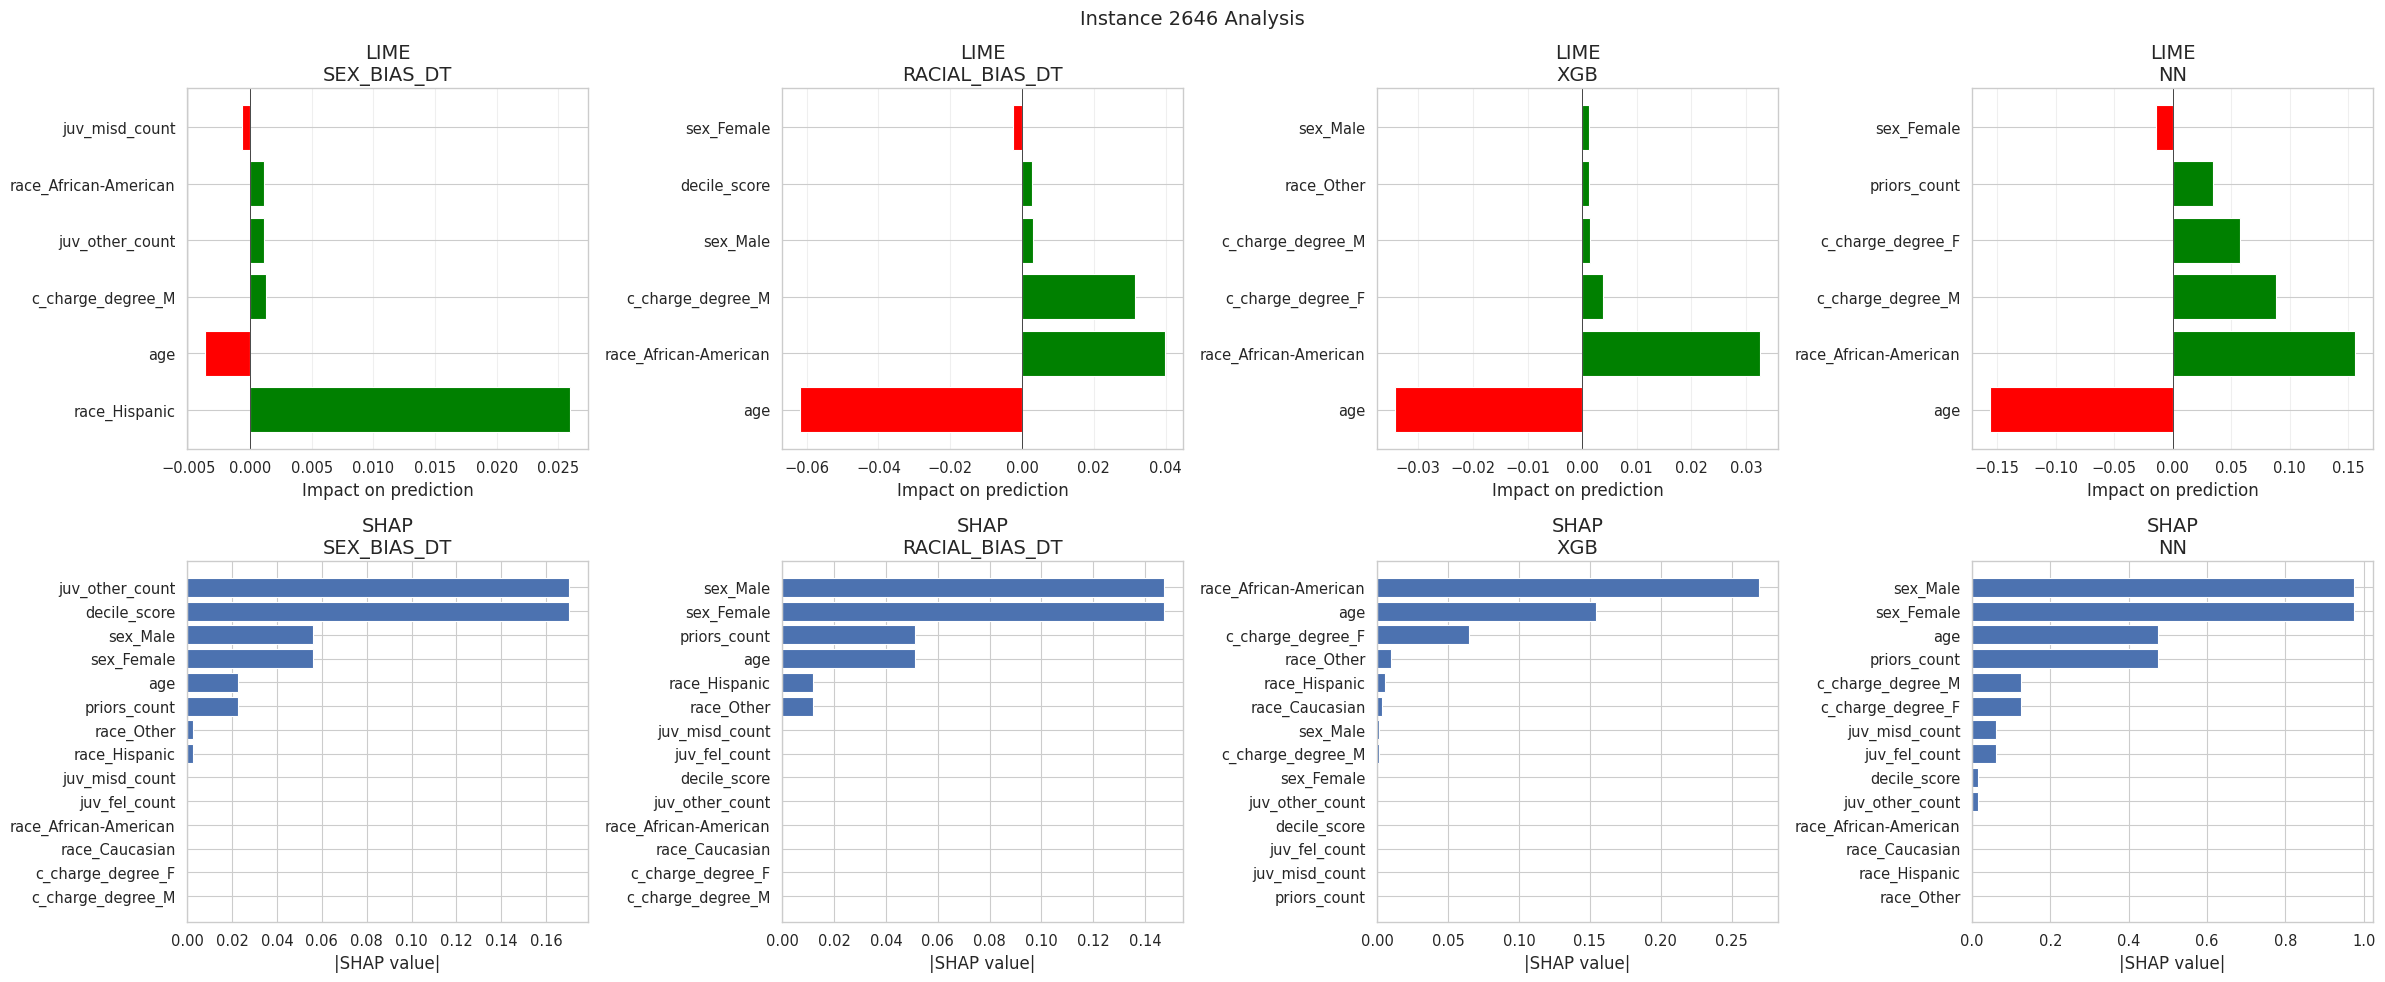


Instance 2844 (True label: No Recidivism)

Actual dataset values:
id                                                  1717
name                                       norence baker
first                                            norence
last                                               baker
compas_screening_date                         2013-09-06
sex                                                 Male
dob                                           1980-09-21
age                                                   35
age_cat                                          25 - 45
race                                    African-American
juv_fel_count                                          0
decile_score                                           6
juv_misd_count                                         0
juv_other_count                                        0
priors_count                                           5
days_b_screening_arrest                             -1.0
c_jail_in            

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


SHAP values shape: (1, 14, 2)
SHAP values shape: (1, 14, 2)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


SHAP values shape: (1, 14)
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
SHAP values shape: (1, 14, 2)


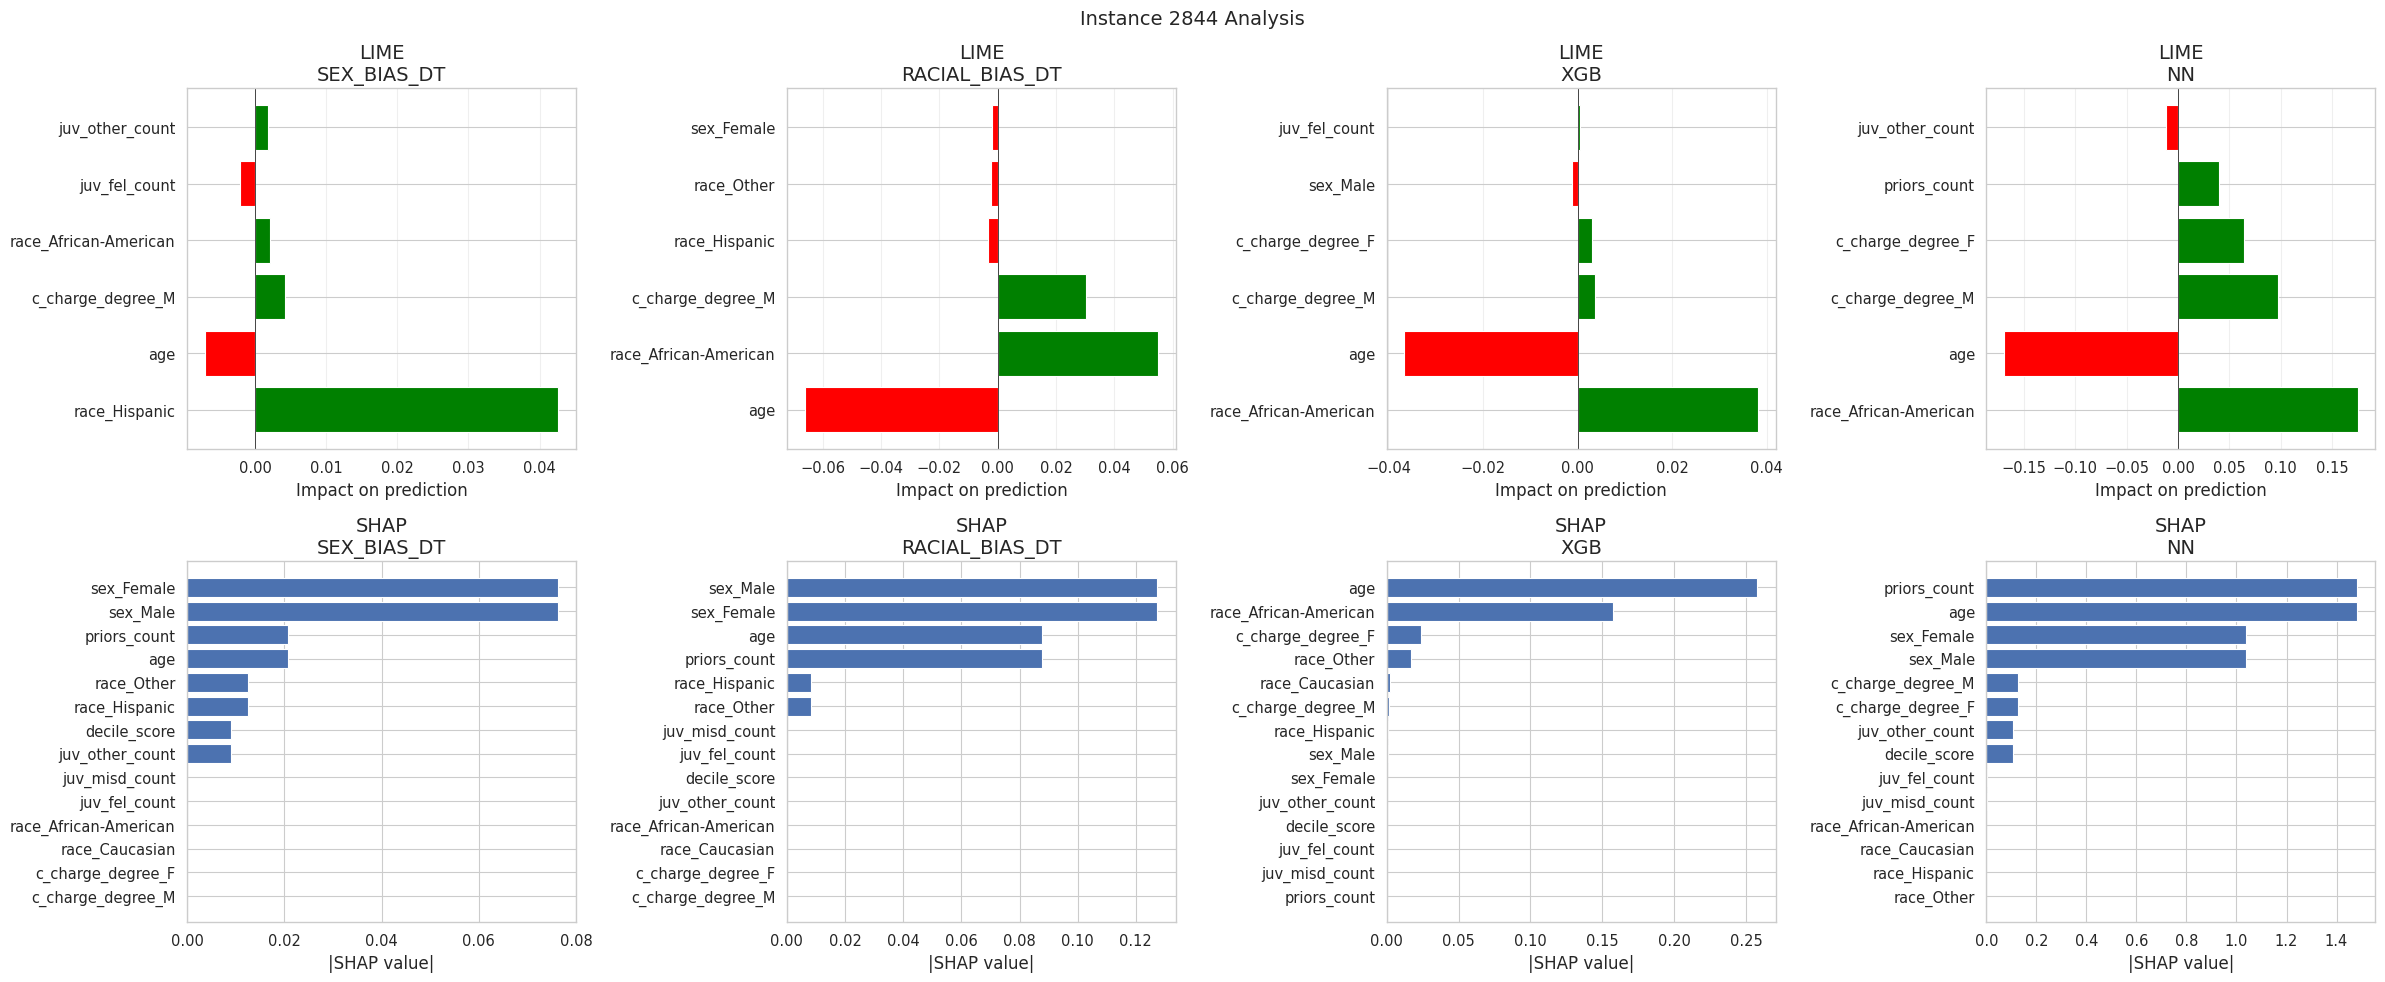

In [8]:
# Run LIME and SHAP Analysis

# Analyze random instances
print("\nAnalyzing 5 random instances...")
random_indices = np.random.choice(len(X_test), 5, replace=False)

for idx in random_indices:
    instance = X_test.iloc[idx]
    true_label = y_test.iloc[idx]

    print("\n" + "="*80)
    print(f"Instance {idx} (True label: {'Recidivism' if true_label == 1 else 'No Recidivism'})")
    print("="*80)

    # Get predictions with proper type conversion
    instance_reshaped = instance.values.reshape(1, -1).astype(np.float32)
    print("\nActual dataset values:")
    print(data.iloc[idx])
    # Get predictions for each model
    try:
        # For tree-based models, get probability of positive class
        sex_bias_pred = models_dict['sex_bias_dt'].predict_proba(instance_reshaped)[0, 1]
        racial_bias_pred = models_dict['racial_bias_dt'].predict_proba(instance_reshaped)[0, 1]
        xgb_pred = models_dict['xgb'].predict_proba(instance_reshaped)[0, 1]

        # For neural network, handle single output
        nn_output = models_dict['nn'].predict(instance_reshaped)
        if nn_output.shape[1] > 1:  # If multiple outputs (probabilities)
            nn_pred = nn_output[0, 1]  # Take probability of positive class
        else:  # If single output (logits/probability)
            nn_pred = nn_output[0, 0]  # Take the single value

        preds = {
            'sex_bias_dt': float(sex_bias_pred),
            'racial_bias_dt': float(racial_bias_pred),
            'xgb': float(xgb_pred),
            'nn': float(nn_pred)
        }

        print("\nDebug - Prediction shapes:")
        print(f"Sex Bias DT pred shape: {models_dict['sex_bias_dt'].predict_proba(instance_reshaped).shape}")
        print(f"Racial Bias DT pred shape: {models_dict['racial_bias_dt'].predict_proba(instance_reshaped).shape}")
        print(f"XGB pred shape: {models_dict['xgb'].predict_proba(instance_reshaped).shape}")
        print(f"NN pred shape: {nn_output.shape}")
    except Exception as e:
        print(f"Error getting predictions: {str(e)}")
        print(f"Shape of instance: {instance_reshaped.shape}")
        print(f"Neural network prediction shape: {models_dict['nn'].predict(instance_reshaped).shape}")
        raise

    # Print predictions
    print("\nPredictions:")
    print("-" * 40)
    for name, pred in preds.items():
        print(f"{name.upper():15} : {pred:.3f}")

    # Create figure for visualizations
    fig, axes = plt.subplots(2, 4, figsize=(24, 10))
    fig.suptitle(f'Instance {idx} Analysis', fontsize=14)

    # Get LIME explanations
    for i, (name, model) in enumerate(models_dict.items()):
        # Define prediction function based on model type
        if name == 'nn':
            # For neural network, wrap the prediction to match expected format
            def nn_predict_fn(x):
                pred = model.predict(x.astype(np.float32))
                if pred.shape[1] == 1:
                    # If single output, convert to two-class probability
                    return np.hstack([1 - pred, pred])
                return pred
            predict_fn = nn_predict_fn
        else:
            predict_fn = model.predict_proba

        exp = lime_exp.explain_instance(instance.values.astype(np.float32), predict_fn, num_features=6)

        # Plot LIME explanation directly
        plt.sca(axes[0, i])
        exp_list = exp.as_list()
        features, values = zip(*exp_list)
        values = [float(v) for v in values]  # Convert to Python floats
        colors = ['green' if v > 0 else 'red' for v in values]
        y_pos = np.arange(len(features))

        # Create horizontal bar chart for LIME
        axes[0, i].barh(y_pos, values, align='center', color=colors)
        axes[0, i].set_yticks(y_pos)
        axes[0, i].set_yticklabels([str(x) for x in features])
        axes[0, i].set_xlabel('Impact on prediction')
        axes[0, i].set_title(f'LIME\n{name.upper()}')
        axes[0, i].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        axes[0, i].grid(True, axis='x', alpha=0.3)

        # Get SHAP values
        try:
            shap_values = shap_exp[name].shap_values(instance_reshaped)
            if isinstance(shap_values, list):
                print(f"SHAP values list length: {len(shap_values)}")
                for i, sv in enumerate(shap_values):
                    print(f"Shape of element {i}: {sv.shape if hasattr(sv, 'shape') else 'no shape'}")
            else:
                print(f"SHAP values shape: {shap_values.shape}")

            # Handle SHAP values based on model type
            if isinstance(shap_values, list):
                # For models that return a list of arrays (one per class)
                if len(shap_values) >= 2:
                    # Take positive class values
                    shap_array = shap_values[1]
                else:
                    # If only one array, use it
                    shap_array = shap_values[0]
            else:
                # For models that return a single array
                shap_array = shap_values

            # Ensure we have the right shape
            if isinstance(shap_array, np.ndarray):
                if shap_array.ndim > 2:
                    shap_array = shap_array.reshape(-1, len(feature_names))
                if shap_array.ndim == 2:
                    shap_array = shap_array[0]  # Take first instance

            # Ensure shap_array is 1D and matches feature_names length
            shap_array = np.array(shap_array).ravel()
            if len(shap_array) != len(feature_names):
                raise ValueError(f"SHAP values length ({len(shap_array)}) doesn't match feature count ({len(feature_names)})")

            # Create horizontal bar chart for SHAP
            plt.sca(axes[1, i])
            importance_values = np.abs(shap_array)

            # Sort by absolute importance
            sort_idx = np.argsort(importance_values)
            sorted_features = [feature_names[j] for j in sort_idx]
            sorted_importance = importance_values[sort_idx]
            y_pos = np.arange(len(sorted_features))

            # Create the plot
            axes[1, i].barh(y_pos, sorted_importance)
            axes[1, i].set_yticks(y_pos)
            axes[1, i].set_yticklabels(sorted_features)
            axes[1, i].set_title(f'SHAP\n{name.upper()}')
            axes[1, i].set_xlabel('|SHAP value|')

        except Exception as e:
            print(f"\nError calculating SHAP values for {name}: {str(e)}")
            # Fill the plot with a message
            axes[1, i].text(0.5, 0.5, 'SHAP values\nnot available',
                          horizontalalignment='center',
                          verticalalignment='center',
                          transform=axes[1, i].transAxes)
            axes[1, i].set_title(f'SHAP\n{name.upper()}')

    plt.tight_layout()
    plt.show()


 90/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
 48/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 88/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


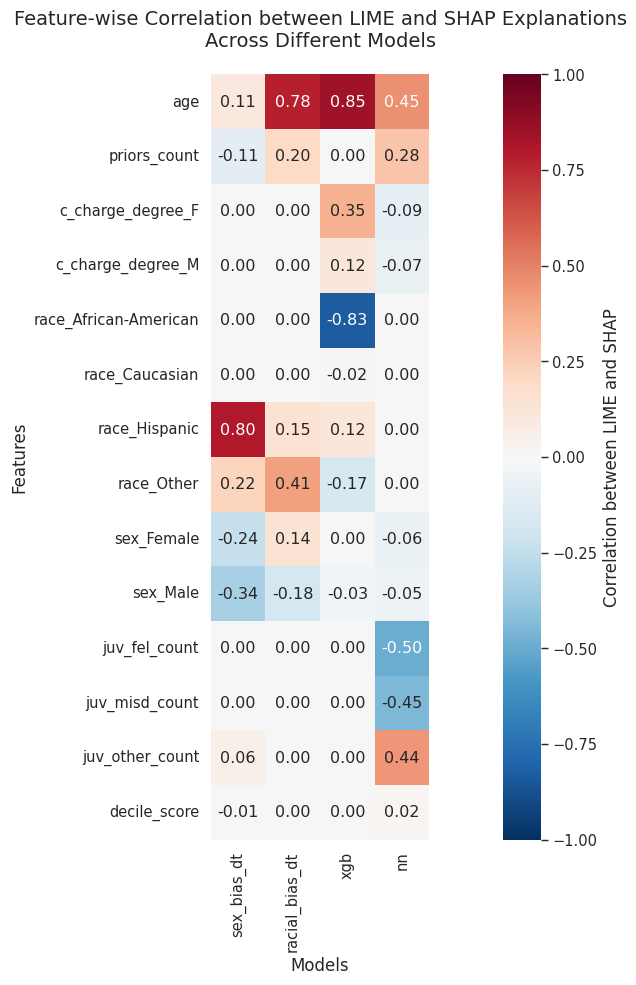


Summary of LIME vs SHAP Agreement by Feature:
--------------------------------------------------

Features ranked by consistency between LIME and SHAP:
age                       Mean correlation:  0.547 ± 0.340
race_Hispanic             Mean correlation:  0.270 ± 0.361 (Constant values in: NN)
juv_other_count           Mean correlation:  0.126 ± 0.213 (Constant values in: RACIAL_BIAS_DT, XGB)
race_Other                Mean correlation:  0.115 ± 0.253 (Constant values in: NN)
priors_count              Mean correlation:  0.093 ± 0.179 (Constant values in: XGB)
c_charge_degree_F         Mean correlation:  0.065 ± 0.196 (Constant values in: SEX_BIAS_DT, RACIAL_BIAS_DT)
c_charge_degree_M         Mean correlation:  0.012 ± 0.080 (Constant values in: SEX_BIAS_DT, RACIAL_BIAS_DT)
decile_score              Mean correlation:  0.002 ± 0.012 (Constant values in: RACIAL_BIAS_DT, XGB)
race_Caucasian            Mean correlation: -0.004 ± 0.009 (Constant values in: SEX_BIAS_DT, RACIAL_BIAS_DT, NN)
se

In [9]:
# Create correlation heatmap between LIME and SHAP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Initialize correlation matrices for each model
correlation_data = {}

def safe_correlation(x, y):
    """Calculate correlation with handling for constant arrays"""
    # Check if either array is constant
    if np.all(x == x[0]) or np.all(y == y[0]):
        if np.array_equal(x, y):  # If both arrays are identical constants
            return 1.0
        else:  # If only one array is constant or they're different constants
            return 0.0
    else:
        return stats.pearsonr(x, y)[0]

# Suppress specific warning about constant input
warnings.filterwarnings('ignore', category=stats.ConstantInputWarning)

# Select random instances for analysis
np.random.seed(42)  # for reproducibility
n_instances = 20
random_indices = np.random.choice(len(X_test), n_instances, replace=False)
test_instances = X_test.iloc[random_indices]

# Initialize storage for explanations
lime_explanations = {
    'sex_bias_dt': [], 'racial_bias_dt': [], 'xgb': [], 'nn': []
}
shap_explanations = {
    'sex_bias_dt': [], 'racial_bias_dt': [], 'xgb': [], 'nn': []
}

# Get explanations for each instance
for idx, instance in test_instances.iterrows():
    instance_reshaped = instance.values.reshape(1, -1).astype(np.float32)

    # Get LIME explanations
    for name, model in models_dict.items():
        if name == 'nn':
            predict_fn = lambda x: np.hstack([1 - model.predict(x.astype(np.float32)),
                                          model.predict(x.astype(np.float32))])
        else:
            predict_fn = model.predict_proba

        exp = lime_exp.explain_instance(
            instance.values.astype(np.float32),
            predict_fn,
            num_features=len(feature_names)
        )
        lime_values = dict(exp.as_list())
        lime_explanations[name].append([lime_values.get(f, 0) for f in feature_names])

    # Get SHAP explanations
    for name, explainer in shap_exp.items():
        shap_values = explainer.shap_values(instance_reshaped)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        shap_values = shap_values.reshape(-1)
        shap_explanations[name].append(shap_values)

# Convert explanations to numpy arrays
for name in models_dict.keys():
    lime_vals = np.abs(np.array(lime_explanations[name]))
    shap_vals = np.abs(np.array(shap_explanations[name]))

    # Calculate correlation for each feature
    correlations = []
    for i in range(len(feature_names)):
        corr = safe_correlation(lime_vals[:, i], shap_vals[:, i])
        correlations.append(corr)

    correlation_data[name] = correlations

# Create DataFrame with correlations
correlation_df = pd.DataFrame(correlation_data, index=feature_names)

# Create heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_df,
            cmap='RdBu_r',  # Red-Blue diverging colormap
            center=0,       # Center the colormap at 0
            vmin=-1,       # Minimum correlation
            vmax=1,        # Maximum correlation
            annot=True,    # Show correlation values
            fmt='.2f',     # Format for correlation values
            square=True,   # Make cells square
            cbar_kws={'label': 'Correlation between LIME and SHAP'})

plt.title('Feature-wise Correlation between LIME and SHAP Explanations\nAcross Different Models', pad=20)
plt.xlabel('Models')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print summary statistics with additional information
print("\nSummary of LIME vs SHAP Agreement by Feature:")
print("-" * 50)

# Calculate mean correlation across models for each feature
mean_correlations = correlation_df.mean(axis=1)
std_correlations = correlation_df.std(axis=1)

# Sort features by average correlation
sorted_features = mean_correlations.sort_values(ascending=False)

print("\nFeatures ranked by consistency between LIME and SHAP:")
for feature in sorted_features.index:
    mean_corr = mean_correlations[feature]
    std_corr = std_correlations[feature]

    # Check if feature has any constant values
    constant_models = []
    for model in correlation_df.columns:
        lime_const = np.all(np.abs(lime_explanations[model])[:, feature_names.index(feature)] ==
                          np.abs(lime_explanations[model])[0, feature_names.index(feature)])
        shap_const = np.all(np.abs(shap_explanations[model])[:, feature_names.index(feature)] ==
                          np.abs(shap_explanations[model])[0, feature_names.index(feature)])
        if lime_const or shap_const:
            constant_models.append(model.upper())

    print(f"{feature:<25} Mean correlation: {mean_corr:6.3f} ± {std_corr:4.3f}", end="")
    if constant_models:
        print(f" (Constant values in: {', '.join(constant_models)})")
    else:
        print()

# Print model-wise statistics
print("\nModel-wise Agreement Statistics:")
print("-" * 50)
for model in correlation_df.columns:
    corrs = correlation_df[model]
    print(f"\n{model.upper()} Model:")
    print(f"Average correlation: {corrs.mean():.3f}")
    print(f"Correlation std: {corrs.std():.3f}")

    # Count features with constant values
    constant_features = []
    for feature in feature_names:
        lime_const = np.all(np.abs(lime_explanations[model])[:, feature_names.index(feature)] ==
                          np.abs(lime_explanations[model])[0, feature_names.index(feature)])
        shap_const = np.all(np.abs(shap_explanations[model])[:, feature_names.index(feature)] ==
                          np.abs(shap_explanations[model])[0, feature_names.index(feature)])
        if lime_const or shap_const:
            constant_features.append(feature)

    if constant_features:
        print(f"Features with constant values: {len(constant_features)}")
        print("Constant features:", ", ".join(constant_features))

    print(f"Features with highest agreement:")
    top_features = corrs.sort_values(ascending=False).head(3)
    for feat, corr in top_features.items():
        print(f"  {feat:<25} Correlation: {corr:.3f}")



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22

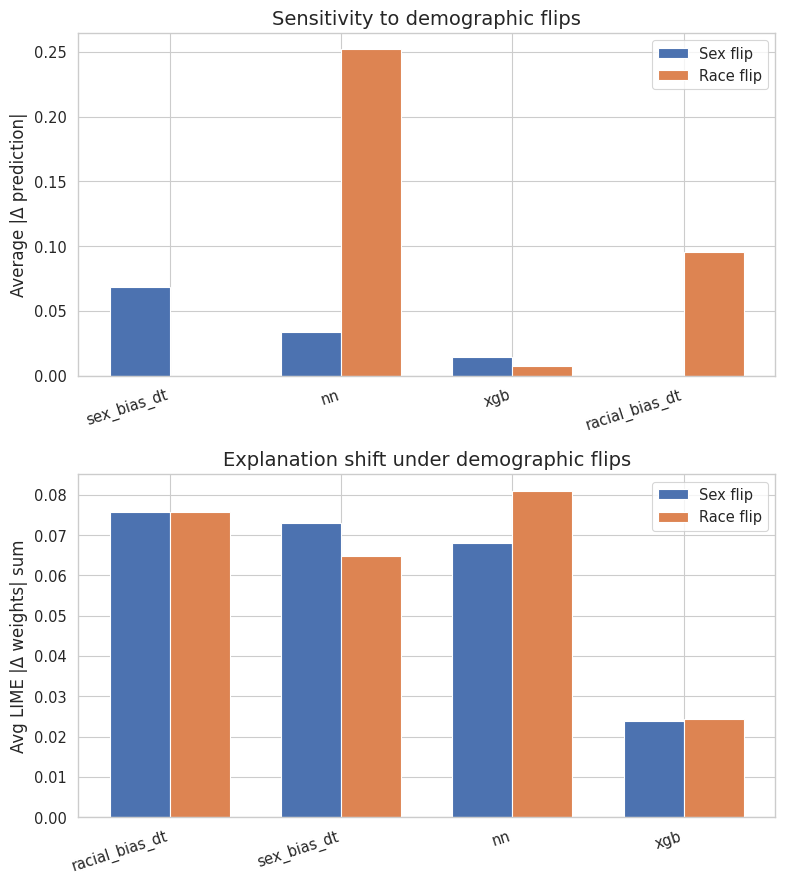


Prediction delta summary, sex flip:


,model,avg_delta,median_delta,std_delta,avg_abs_delta,p90_abs_delta
0,sex_bias_dt,-0.020003,0.006248,0.130914,0.068265,0.320746
1,nn,-0.016991,-0.012561,0.050733,0.033921,0.079422
2,xgb,-0.008246,-0.003298,0.016949,0.014451,0.029734
3,racial_bias_dt,0.000000,0.000000,0.000000,0.000000,0.000000



Prediction delta summary, race flip:


,model,avg_delta,median_delta,std_delta,avg_abs_delta,p90_abs_delta
0,sex_bias_dt,0.000000,0.000000,0.000000,0.000000,0.000000
1,nn,0.003712,-0.085172,0.317921,0.251941,0.548017
2,xgb,-0.001342,-0.000293,0.008171,0.007127,0.011479
3,racial_bias_dt,-0.031595,0.000000,0.116866,0.095672,0.173255



LIME attribution delta summary, sex flip:


,model,avg_lime_sumabs_delta,median_lime_sumabs_delta,std_lime_sumabs_delta,p90_lime_sumabs_delta
0,racial_bias_dt,0.075801,0.076392,0.021510,0.100037
1,sex_bias_dt,0.072887,0.071053,0.014358,0.089034
2,nn,0.067982,0.067086,0.013178,0.086866
3,xgb,0.023762,0.023307,0.004493,0.029654



LIME attribution delta summary, race flip:


,model,avg_lime_sumabs_delta,median_lime_sumabs_delta,std_lime_sumabs_delta,p90_lime_sumabs_delta
0,racial_bias_dt,0.075720,0.073741,0.015467,0.097663
1,sex_bias_dt,0.064721,0.066089,0.012979,0.079558
2,nn,0.081052,0.077598,0.021252,0.102192
3,xgb,0.024362,0.023352,0.005183,0.030116


In [10]:
# Fast counterfactual bias check across models, with aligned bar charts
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display

def _2d(X): X=np.asarray(X); return X.reshape(1,-1) if X.ndim==1 else X
def _model_cols(m, fallback): return list(getattr(m, "feature_names_in_", list(fallback)))
def _to_df(X, cols): X=_2d(X); return pd.DataFrame(X, columns=cols if X.shape[1]==len(cols) else [f"c{i}" for i in range(X.shape[1])])
def _align(X, cols):
    X = _to_df(X, cols) if isinstance(X, (np.ndarray, list)) else pd.DataFrame(X).copy()
    for c in cols:
        if c not in X.columns: X[c]=0.0
    return X[cols]
def _proba(m, X, cols):
    Xa=_align(X, cols)
    if hasattr(m,"predict_proba"):
        p=m.predict_proba(Xa); p=np.asarray(p);
        return np.vstack([1-p, p]).T if p.ndim==1 else p
    if hasattr(m,"decision_function"):
        s=np.asarray(m.decision_function(Xa)).reshape(-1); p1=1/(1+np.exp(-s)); return np.vstack([1-p1,p1]).T
    y=np.asarray(m.predict(Xa)).reshape(-1).astype(float); y=np.clip(y,0,1); return np.vstack([1-y,y]).T
def _lime_fn(m, mcols, inc_cols):
    def fn(X):
        if isinstance(X,np.ndarray): X=_to_df(X, inc_cols)
        elif not isinstance(X,pd.DataFrame): X=_to_df(np.array(X), inc_cols)
        return _proba(m, X, mcols)
    return fn
def _pick_races(cols):
    r=[c for c in cols if c.startswith("race_")]
    if len(r)<2: return None
    return ("race_African-American","race_Caucasian") if {"race_African-American","race_Caucasian"}.issubset(r) else (r[0],r[1])
def flip_demo(X, kind="sex"):
    Xc=X.copy()
    if kind=="sex" and {"sex_Male","sex_Female"}.issubset(Xc.columns): Xc[["sex_Male","sex_Female"]]=Xc[["sex_Female","sex_Male"]].values
    if kind=="race":
        pair=_pick_races(Xc.columns)
        if pair: a,b=pair; Xc[a],Xc[b]=Xc[b].copy(),Xc[a].copy()
    return Xc

# -------- main --------
def compare_fast(X_test, models, lime_exp, feat_names, flip="sex", n=60, seed=42, kfeat=12, ksamples=700, only=None):
    rng=np.random.RandomState(seed); idx=rng.choice(len(X_test), size=min(n,len(X_test)), replace=False)
    Xo, Xc = X_test.iloc[idx].copy(), flip_demo(X_test.iloc[idx].copy(), kind=flip)
    inc_cols=list(X_test.columns)
    pred_rows, lime_rows, pair_rows = [], [], []
    items = [(k,v) for k,v in models.items() if (only is None or k in only)]
    for name, m in items:
        mcols=_model_cols(m, feat_names)
        p_o=_proba(m, Xo, mcols)[:,1]; p_c=_proba(m, Xc, mcols)[:,1]; d=p_c-p_o
        pred_rows.append({"model":name,"avg_delta":d.mean(),"median_delta":np.median(d),"std_delta":d.std(),"avg_abs_delta":np.abs(d).mean(),"p90_abs_delta":np.percentile(np.abs(d),90)})
        pf=_lime_fn(m, mcols, inc_cols); k=min(kfeat, len(inc_cols))
        d_l=[]; XoV, XcV = Xo.values, Xc.values
        for i in range(len(Xo)):
            eo=lime_exp.explain_instance(_2d(XoV[i]).ravel(), pf, num_features=k, num_samples=ksamples)
            ec=lime_exp.explain_instance(_2d(XcV[i]).ravel(), pf, num_features=k, num_samples=ksamples)
            def wd(e):
                dct={}
                for f,w in e.as_list():
                    key=f.split(" ")[0]; dct[key]=dct.get(key,0.0)+float(w)
                return dct
            do, dc = wd(eo), wd(ec); keys=set(do)|set(dc)
            s=float(np.sum([abs(do.get(t,0)-dc.get(t,0)) for t in keys])); d_l.append(s)
            pair_rows.append({"model":name,"row_index":int(idx[i]),"delta_pred":float(d[i]),"delta_lime_sumabs":s})
        lime_rows.append({"model":name,"avg_lime_sumabs_delta":np.mean(d_l),"median_lime_sumabs_delta":np.median(d_l),"std_lime_sumabs_delta":np.std(d_l),"p90_lime_sumabs_delta":np.percentile(d_l,90)})
    return (pd.DataFrame(pred_rows).sort_values("avg_abs_delta",ascending=False).reset_index(drop=True),
            pd.DataFrame(lime_rows).sort_values("avg_lime_sumabs_delta",ascending=False).reset_index(drop=True),
            pd.DataFrame(pair_rows))

# Run fast for sex and race
dfp_sex, dfl_sex, _ = compare_fast(X_test, models_dict, lime_exp, feature_names, flip="sex", n=60, seed=42, kfeat=12, ksamples=700)
dfp_race, dfl_race, _ = compare_fast(X_test, models_dict, lime_exp, feature_names, flip="race", n=60, seed=43, kfeat=12, ksamples=700)

# Align model order for bars
dfp_race = dfp_race.set_index("model").reindex(dfp_sex["model"]).reset_index()
dfl_race = dfl_race.set_index("model").reindex(dfl_sex["model"]).reset_index()

# Bar charts
labels=list(dfp_sex["model"]); x=np.arange(len(labels)); w=0.35
plt.figure(figsize=(max(8,len(labels)*1.1),9))
plt.subplot(2,1,1)
plt.bar(x-w/2, dfp_sex["avg_abs_delta"], w, label="Sex flip")
plt.bar(x+w/2, dfp_race["avg_abs_delta"], w, label="Race flip")
plt.xticks(x, labels, rotation=18, ha="right"); plt.ylabel("Average |Δ prediction|"); plt.title("Sensitivity to demographic flips"); plt.legend()
plt.subplot(2,1,2)
labels2=list(dfl_sex["model"]); x2=np.arange(len(labels2))
plt.bar(x2-w/2, dfl_sex["avg_lime_sumabs_delta"], w, label="Sex flip")
plt.bar(x2+w/2, dfl_race["avg_lime_sumabs_delta"], w, label="Race flip")
plt.xticks(x2, labels2, rotation=18, ha="right"); plt.ylabel("Avg LIME |Δ weights| sum"); plt.title("Explanation shift under demographic flips"); plt.legend()
plt.tight_layout(); plt.show()

print("\nPrediction delta summary, sex flip:"); display(dfp_sex)
print("\nPrediction delta summary, race flip:"); display(dfp_race)
print("\nLIME attribution delta summary, sex flip:"); display(dfl_sex)
print("\nLIME attribution delta summary, race flip:"); display(dfl_race)


Created directory: /mnt/data
Saved heatmap to: /mnt/data/lime_group_heatmap.png


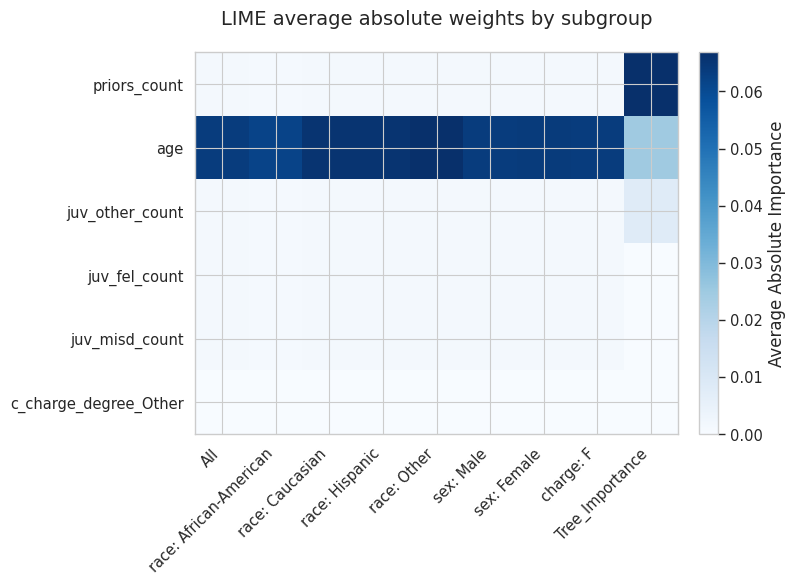

Heatmap data:


,All,race: African-American,race: Caucasian,race: Hispanic,race: Other,sex: Male,sex: Female,charge: F,Tree_Importance
priors_count,0.001066,0.000951,0.001313,0.001351,0.001510,0.001097,0.001174,0.001083,0.640818
age,0.063565,0.061641,0.065776,0.065700,0.066855,0.063630,0.063965,0.063522,0.236888
juv_other_count,0.001057,0.000967,0.001332,0.001296,0.001416,0.001165,0.001207,0.001088,0.076212
juv_fel_count,0.001100,0.000969,0.001267,0.001378,0.001346,0.001251,0.001143,0.001065,0.000000
juv_misd_count,0.001051,0.000984,0.001236,0.001312,0.001307,0.001075,0.001092,0.001089,0.000000
c_charge_degree_Other,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [11]:
# Heatmap of LIME average absolute weights by subgroup vs global tree importance
# Requires: X_test, feature_names, models_dict, lime_exp already defined

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os # Import the os module1
import re # Import the regex module

def _get_tree_model(models_dict):
    for k in ["racial_bias_dt"]:
        if k in models_dict:
            return models_dict[k], k
    # If none of the preferred keys are found, return the first tree-based model found
    for name, model in models_dict.items():
        if hasattr(model, "feature_importances_"):
            return model, name
    raise ValueError("No tree-based model found in models_dict")

def _predict_fn_df(model, feature_names):
    # Use the model's internal feature names if available, otherwise use the provided list
    model_feature_names = list(getattr(model, 'feature_names_in_', feature_names))

    def _fn(X):
        if isinstance(X, np.ndarray):
            # Ensure the DataFrame has the correct columns and order
            # Create DataFrame with the names LIME passes (using provided feature_names)
            X = pd.DataFrame(X, columns=feature_names)
            # Reindex to match model's expected features, adding missing columns with 0
            X = X.reindex(columns=model_feature_names, fill_value=0)
        elif isinstance(X, pd.DataFrame):
             # If already a DataFrame, just reindex
             X = X.reindex(columns=model_feature_names, fill_value=0)

        # Ensure column order matches the model's expected order before predicting
        X = X[model_feature_names]

        return model.predict_proba(X)
    return _fn


def compute_lime_avg_weights(X_subset, model, lime_exp, feature_names, sample_size=200, random_state=42):
    if len(X_subset) == 0:
        return np.zeros(len(feature_names))
    n = min(sample_size, len(X_subset))
    sample = X_subset.sample(n, random_state=random_state)
    avg = np.zeros(len(feature_names), dtype=float)
    predict_fn = _predict_fn_df(model, feature_names) # Use the updated predict_fn

    for row in sample.values:
        exp = lime_exp.explain_instance(row, predict_fn, num_features=len(feature_names))
        for feat, weight in exp.as_list():
            match = re.match(r'([a-zA-Z_]+)', feat)
            if match:
                fname = match.group(1)
                if fname in feature_names:
                    j = feature_names.index(fname)
                    avg[j] += abs(weight)
    return avg / n

def build_group_masks(X_test):
    groups = {}
    candidate_cols = [
        "race_African-American", "race_Caucasian", "race_Hispanic", "race_Other",
        "race_Asian", "race_Native American", "sex_Male", "sex_Female",
        "c_charge_degree_F", "c_charge_degree_M"
    ]
    for col in candidate_cols:
        if col in X_test.columns:
            mask = X_test[col] == 1
            if mask.sum() >= 30:
                groups[col] = mask
    # Ensure 'All' group is a Series with the correct index
    groups = {"All": pd.Series(True, index=X_test.index)} | groups
    return groups

def lime_importance_heatmap_clean(
    X_test, models_dict, lime_exp, feature_names,
    top_k=15, sample_size=300, random_state=42,
    exclude_prefixes=("race_", "sex_"),
    save_path="/mnt/data/lime_group_heatmap.png"
):
    model, model_key = _get_tree_model(models_dict)
    # Retrieve the feature names the model was trained on
    model_feature_names = list(getattr(model, 'feature_names_in_', feature_names))

    if not hasattr(model, "feature_importances_"):
        # If feature_importances_ is not available, try to compute it from the model
        if hasattr(model, 'estimators_') and isinstance(model.estimators_[0], xgb.XGBoost):
            # This is a multi-tree model like XGBoost, get importance from the first tree
            # Note: This is a simplification, true XGBoost importance is more complex
            print("Warning: Using feature_importances_ from the first tree in a multi-tree model.")
            tree_imp = np.asarray(model.feature_importances_, dtype=float)
        elif hasattr(model, 'tree_') and hasattr(model.tree_, 'compute_feature_importances'):
             # For scikit-learn DecisionTree
             tree_imp = np.asarray(model.feature_importances_, dtype=float)
        else:
             raise ValueError("Selected model lacks feature_importances_ and cannot compute it.")


    tree_imp = np.asarray(model.feature_importances_, dtype=float) # Use model's feature importances
    groups = build_group_masks(X_test)

    group_names = list(groups.keys())
    # Ensure the matrix uses the feature names that will be in the rows of the heatmap
    row_feature_names = _exclude_features(model_feature_names, exclude_prefixes=exclude_prefixes)
    mat = np.zeros((len(row_feature_names), len(group_names)), dtype=float)

    # Create a mapping from the full model feature names to the row feature names indices
    model_name_to_row_idx = {name: i for i, name in enumerate(row_feature_names)}

    for gi, gname in enumerate(group_names):
        mask = groups[gname]
        Xg = X_test[mask]
        # Compute LIME weights for all model features
        weights_all_features = compute_lime_avg_weights(
            X_subset=Xg,
            model=model,
            lime_exp=lime_exp,
            feature_names=model_feature_names, # Pass model feature names to compute_lime_avg_weights
            sample_size=sample_size,
            random_state=random_state
        )
        # Populate the matrix only for the row_feature_names
        for i, fname in enumerate(model_feature_names):
            if fname in row_feature_names:
                 mat[model_name_to_row_idx[fname], gi] = weights_all_features[i]


    # Filter tree importance to the row features
    model_name_to_idx = {name: i for i, name in enumerate(model_feature_names)}
    tree_imp_rows = np.array([tree_imp[model_name_to_idx[name]] for name in row_feature_names])


    # Pick top_k rows based on the filtered tree importance
    top_idx = np.argsort(-tree_imp_rows)[:min(top_k, len(row_feature_names))]
    features_top = [row_feature_names[i] for i in top_idx]
    mat_top = mat[top_idx, :]
    tree_imp_top = tree_imp_rows[top_idx]

    if mat_top.max() > 0:
        # Scale tree importance relative to the max LIME value in the top features
        scale = mat_top.max()
        # Avoid division by zero for scaling if all tree importances are zero
        if tree_imp_top.max() > 1e-12:
             ti_col = (tree_imp_top / tree_imp_top.max()) * scale
        else:
             ti_col = tree_imp_top * 0 # If tree importances are all zero, scaled importance is zero
    else:
        # If all LIME values are zero, set scaled tree importance to the raw tree importance
        ti_col = tree_imp_top


    mat_plot = np.concatenate([mat_top, ti_col.reshape(-1, 1)], axis=1)
    group_labels = [_pretty_group(k) if k != "All" else "All" for k in group_names] + ["Tree_Importance"]


    plt.figure(figsize=(max(7, (len(group_labels)) * 0.9), max(6, len(features_top) * 0.35)))
    im = plt.imshow(mat_plot, aspect="auto", cmap='Blues') # Use a standard colormap
    plt.colorbar(im, fraction=0.046, pad=0.04, label='Average Absolute Importance') # Add colorbar label
    plt.yticks(range(len(features_top)), features_top)
    plt.xticks(range(len(group_labels)), group_labels, rotation=45, ha="right") # Rotate x-axis labels
    plt.title("LIME average absolute weights by subgroup", pad=20) # Add padding to title
    plt.tight_layout()

    # Create directory if it doesn't exist
    save_dir = os.path.dirname(save_path)
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        print(f"Created directory: {save_dir}")

    try:
        plt.savefig(save_path, dpi=160, bbox_inches='tight') # Use bbox_inches='tight' to prevent labels from being cut off
        print(f"Saved heatmap to: {save_path}")
    except Exception as e:
        print(f"Error saving heatmap to {save_path}: {e}")


    plt.show()

    df = pd.DataFrame(mat_top, index=features_top, columns=[_pretty_group(k) if k != "All" else "All" for k in group_names])
    df["Tree_Importance"] = tree_imp_top
    return df, save_path

def _pretty_group(col):
    # Improve readability of subgroup column names
    col = col.replace("_", " ")
    col = col.replace("race ", "race: ")
    col = col.replace("sex ", "sex: ")
    col = col.replace("c charge degree ", "charge: ")
    return col

def _exclude_features(feature_names, exclude_prefixes=("race_", "sex_")):
    # Drop protected-attribute one-hots from the ROWS of the heatmap
    keep = []
    for f in feature_names:
        if any(f.startswith(p) for p in exclude_prefixes):
            continue
        keep.append(f)
    return keep
# -------------------- run --------------------

df_heatmap, heatmap_path = lime_importance_heatmap_clean(
    X_test=X_test,
    models_dict=models_dict,
    lime_exp=lime_exp,
    feature_names=feature_names, # Assuming feature_names is the list of all features after preprocessing
    top_k=15,
    sample_size=300,
    random_state=42,
    exclude_prefixes=("race_", "sex_"),  # keep sensitive one-hots out of the rows
    save_path="/mnt/data/lime_group_heatmap.png"
)

print(f"Heatmap data:")
display(df_heatmap.head(20))

Successfully loaded data with shape: (18316, 52)
Available columns in dataset: ['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event']

Preprocessing steps:
1. Handling missing values...
2. Converting categorical variables...

Verifying featur

/tmp/ipython-input-86841138.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


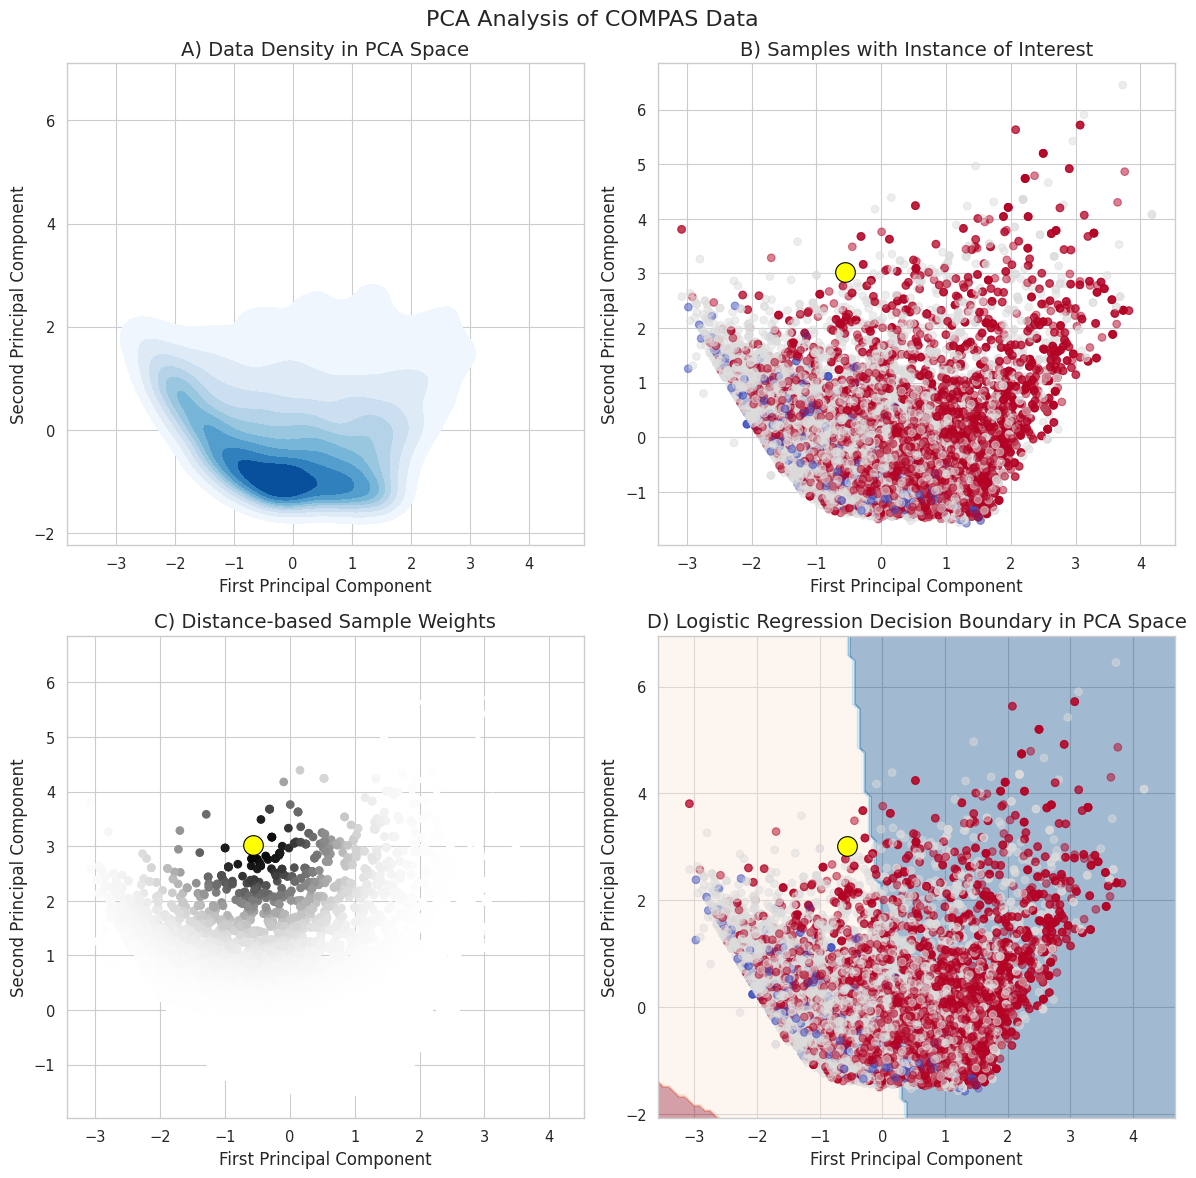


Explained variance ratio for first two components:
PC1: 0.3928 (39.3%)
PC2: 0.3015 (30.1%)


In [21]:
# Load and preprocess the data
data = load_data()
train_data, test_data = preprocess_data(data)

# Get the training features and labels
X_train_scaled = train_data[0]
y_train = train_data[1]

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# Create a grid for the prediction surface
x1_min, x1_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
x2_min, x2_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100),
                      np.linspace(x2_min, x2_max, 100))

# Create figure with four subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('PCA Analysis of COMPAS Data', fontsize=16)

# A) Data Density in PCA Space
sns.kdeplot(data=pd.DataFrame(X_pca, columns=['PC1', 'PC2']),
            x='PC1', y='PC2', fill=True, cmap='Blues',
            ax=ax1)
ax1.set_title('A) Data Density in PCA Space')

# B) Instance of interest and samples
scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train,
                     cmap='coolwarm', alpha=0.5, s=30)
# Highlight a random instance of interest
instance_idx = np.random.randint(len(X_pca))
ax2.scatter(X_pca[instance_idx, 0], X_pca[instance_idx, 1],
            color='yellow', s=200, marker='o', edgecolor='black')
ax2.set_title('B) Samples with Instance of Interest')

# C) Distance-based weights
distances = np.sqrt(np.sum((X_pca - X_pca[instance_idx])**2, axis=1))
weights = np.exp(-(distances**2)/2)
scatter = ax3.scatter(X_pca[:, 0], X_pca[:, 1], c=weights,
                     cmap='Greys', s=30)
ax3.scatter(X_pca[instance_idx, 0], X_pca[instance_idx, 1],
            color='yellow', s=200, marker='o', edgecolor='black')
ax3.set_title('C) Distance-based Sample Weights')

# D) Decision boundary visualization
# Train a simple model on PCA-transformed data to plot decision boundary
from sklearn.linear_model import LogisticRegression
model_pca = LogisticRegression(random_state=RANDOM_STATE)
model_pca.fit(X_pca, y_train)

# Predict on the grid points
grid_points = np.c_[xx1.ravel(), xx2.ravel()]
Z = model_pca.predict(grid_points)
Z = Z.reshape(xx1.shape)


# Plot decision boundary using the model's predictions on the grid
ax4.contourf(xx1, xx2, Z, alpha=0.4,
             cmap='RdBu')
ax4.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train,
                     cmap='coolwarm', alpha=0.5, s=30) # Plot original points
ax4.scatter(X_pca[instance_idx, 0], X_pca[instance_idx, 1],
            color='yellow', s=200, marker='o', edgecolor='black') # Highlight instance
ax4.set_title('D) Logistic Regression Decision Boundary in PCA Space')

# Common settings for all subplots
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel('First Principal Component')
    ax.set_ylabel('Second Principal Component')
    ax.grid(True)

plt.tight_layout()
plt.show()

# Print explained variance for first two components
print("\nExplained variance ratio for first two components:")
for i, var in enumerate(pca.explained_variance_ratio_, 1):
    print(f"PC{i}: {var:.4f} ({var*100:.1f}%)")